In [1]:
import os
import sys
import dill
import pprint
from pathlib import Path
import itertools
import pathos
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')

import numpy as np
import jax.numpy as jnp
import functools
import pandas as pd
from numpyro.diagnostics import gelman_rubin

from matplotlib import pyplot as plt
import seaborn as sns

from src import MultivariateTPrior, ExponentialPrior, LogisticSource, PosteriorUtilities, StandardLogisticSource, StudentTSource, MMSEBarkerMHEstimator
np.random.seed(100)

In [2]:
# # Whether or not to create config
# EXECUTE=True

# # Whether or not to create folder structure
# CREATE_FOLDER_STRUCTURE=True

# # Experiment name
# EXPERIMENT_NAME='posterior_t_student_var1m_50ksamples'

# # Folder which will contain output directory tree
# OUTPUT_DIR='./output'
# base_output_path=Path(OUTPUT_DIR)

# # Create experiment directory
# experiment_dir = base_output_path / EXPERIMENT_NAME

# 1. Definir classes

## ImportanceSamplingEstimator

In [3]:
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Optional, Sequence, Union
import warnings

import numpy as np
import pandas as pd

try:
    from tqdm import tqdm
    _HAS_TQDM = True
except ImportError:
    _HAS_TQDM = False


PriorLike = Union[Callable, object]     # a bare pdf callable, or an object with .get()


@dataclass
class ImportanceSamplingResult:
    """Container for the SNIS result of a single target prior."""
    name: str
    mean_estimate: np.ndarray          # SNIS posterior mean estimate (same shape as B)
    weights: np.ndarray                # normalized weights (sum to 1), shape (N,)
    log_weights: np.ndarray            # raw (max-centered) log-weights, shape (N,)
    ess: float                         # Kish's effective sample size
    ess_ratio: float                   # ess / n_samples
    max_weight: float                  # largest normalized weight
    n_samples: int
    reliable: bool                     # convenience flag, see `ess_ratio_thresh`

    def summary(self) -> Dict:
        return {
            'name': self.name,
            'mean_estimate': self.mean_estimate,
            'ess': self.ess,
            'ess_ratio': self.ess_ratio,
            'max_weight': self.max_weight,
            'n_samples': self.n_samples,
            'reliable': self.reliable,
        }


class ImportanceSamplingEstimator:
    """
    Self-normalized importance sampling estimator of posterior means under
    a list of alternative priors, reusing one set of previously-drawn MCMC
    samples.
    """

    # ------------------------------------------------------------------ #
    # 1) Sample extraction: accept estimators, arrays, or lists           #
    # ------------------------------------------------------------------ #
    # @staticmethod
    # def extract_samples(source) -> np.ndarray:
    #     """
    #     Extracts an (N, ...) array of posterior samples ("B" matrices) from
    #     a variety of inputs, so a fitted estimator can be passed directly.

    #     Accepts, in order of priority:
    #         1. A fitted estimator exposing `.mcmc_results['samples']`
    #            (MMSEBarkerMHEstimator / MMSEMetropolisHastingsEstimator
    #            after `.fit(...)`) -- this is the burn-in-removed, merged,
    #            stationary sample set and is the recommended source.
    #         2. A fitted estimator exposing `.samples` (raw per-chain array).
    #         3. A numpy array / list / tuple of samples directly.
    #     """
    #     if hasattr(source, 'mcmc_results') and isinstance(source.mcmc_results, dict) \
    #             and 'samples' in source.mcmc_results:
    #         return np.asarray(source.mcmc_results['samples'])
    #     if hasattr(source, 'samples'):
    #         samples = np.asarray(source.samples)
    #         # Per-chain arrays (chains, iterations, p, q) are flattened into
    #         # (chains * iterations, p, q) so every draw is treated as one
    #         # importance-sampling particle.
    #         if samples.ndim == 4:
    #             samples = samples.reshape((-1,) + samples.shape[-2:])
    #         return samples
    #     if isinstance(source, (np.ndarray, list, tuple)):
    #         return np.asarray(source)
    #     raise TypeError(
    #         "Could not extract samples from `source`. Expected a fitted "
    #         "estimator exposing `.mcmc_results['samples']` or `.samples`, "
    #         "or a numpy array / list / tuple of samples. Got: "
    #         f"{type(source)!r}"
    #     )

    @classmethod
    def __resolve_experiment(
        cls,
        baseline_prior,
        target_priors,
        prior_control_params,
        baseline_source_model,
        target_source_models,
        source_model_control_params
    ):
        impsamp_configs = {}

        # Error: nothing specified
        if (
            (baseline_prior is None) and 
            (target_priors is None) and 
            (baseline_source_model is None) and
            (target_source_models is None)
        ):
            raise ValueError('Neither priors and source models are specified.')
        
        # Only prior variations specified
        if (
            (baseline_prior is not None) and 
            (target_priors is not None) and 
            (baseline_source_model is not None) and
            (target_source_models is None)
        ):
            impsamp_configs['prior_variation'] = {
                'target_priors': [p.get() for p in target_priors], 
                'baseline_prior': baseline_prior.get(),
                'params': prior_control_params
            }

        # Only source model variations specified
        if (
            (baseline_prior is not None) and 
            (target_priors is None) and 
            (baseline_source_model is not None) and
            (target_source_models is not None)
        ):
            impsamp_configs['source_model_variation'] = {
                'target_posteriors': [
                    PosteriorUtilities.get_log_posterior_fn(
                        source_pdf_fn=sm,
                        prior_pdf_fn=baseline_prior.get()
                    ) for sm in target_source_models
                ],
                'baseline_posterior': PosteriorUtilities.get_log_posterior_fn(
                    source_pdf_fn=baseline_source_model.get(),
                    prior_pdf_fn=baseline_prior.get()
                ),
                'params': source_model_control_params
            }

        # Both prior and source model variations specified
        if (
            (baseline_prior is not None) and 
            (target_priors is not None) and 
            (baseline_source_model is not None) and
            (target_source_models is not None)
        ):
            impsamp_configs['prior_source_model_variation'] = {
                'target_posteriors': [
                    PosteriorUtilities.get_log_posterior_fn(
                        source_pdf_fn=sm.get(),
                        prior_pdf_fn=p.get()
                    ) for p, sm in itertools.product(
                        target_priors,
                        target_source_models
                    )
                ],
                'baseline_posterior': PosteriorUtilities.get_log_posterior_fn(
                    source_pdf_fn=baseline_source_model.get(),
                    prior_pdf_fn=baseline_prior.get()
                ),
                'params': itertools.product(
                    prior_control_params,
                    source_model_control_params
                )
            }

        cls.impsamp_configs = impsamp_configs
        

    @classmethod
    def __get_log_weights(
        cls,
        samples: np.ndarray,
        x
    ) -> np.ndarray:
        def __get_one_prior(
            samples,
            baseline_prior,
            target_prior
        ):
            w_p=[]
            for B_k in samples:
                weight = target_prior(
                    B=B_k
                )/baseline_prior(
                    B=B_k
                )
                w_p.append(weight)

            return w_p
            
        def __get_one_posterior(
            samples,
            baseline_post,
            x,
            post
        ):
            w_p=[]
            for B_k in samples:
                weight = post(
                    x=x,
                    B=B_k
                ) - baseline_post(
                    x=x,
                    B=B_k
                )
                w_p.append(weight)

            return np.exp(w_p)
            
        
        impsamp_results = cls.impsamp_configs
        # Ge weights for prior variation analysis
        impsamp_results['prior_variation']['weights'] = []
        for target_prior in tqdm(impsamp_results['prior_variation']['target_priors']):
            impsamp_results['prior_variation']['weights'].append(
                __get_one_prior(
                    samples=samples,
                    baseline_prior=impsamp_results['prior_variation']['baseline_prior'],
                    target_prior=target_prior
                )
            )
        # impsamp_results['prior_variation']['weights'] = [
        #     __get_one_prior(
        #         samples=samples,
        #         baseline_prior=impsamp_results['prior_variation']['baseline_prior'],
        #         target_prior=target_prior
        #     ) for target_prior in impsamp_results['prior_variation']['target_priors']
        # ]
        
        # impsamp_results[analysis_type]['weights'] = [
        #     __get_one_posterior(
        #         samples=samples,
        #         baseline_post=analysis_params['baseline_posterior'],
        #         x=x,
        #         post=target_post
        #     ) for target_post in analysis_params['target_posteriors']
        # ]
            

        cls.impsamp_results = impsamp_results

    @classmethod
    def __get_estimates(
        cls,
        samples
    ):
        def __get_moments(
            samples,
            weights
        ):
            import time
            # Get sum total of weights
            sum_weights = np.sum(weights)
            
            # Get mean
            B_mean = np.sum([
                s*w for s, w in zip(samples, weights)
            ], axis=0)/sum_weights

            # Differences wrt mean
            mean_diffs = np.array([
                np.subtract(
                    s,
                    B_mean
                ) for s in samples
            ])

            # Get variance 
            B_var = np.sum([
                w*np.power(d, 2) for d, w in zip(mean_diffs, weights)
            ], axis=0)/sum_weights

            # Get skew 
            B_skew = np.sum([
                w*np.power(d, 3) for d, w in zip(mean_diffs, weights)
            ], axis=0)/sum_weights

            # Get kurtosis 
            B_kurt = np.sum([
                w*np.power(d, 4) for d, w in zip(mean_diffs, weights)
            ], axis=0)/sum_weights

            return {
                'mean': B_mean,
                'var': B_var,
                'skew': B_skew,
                'kurt': B_kurt
            }
        
        for analysis_type, analysis_params in cls.impsamp_results.items():
            analysis_params['means'] = []
            analysis_params['vars'] = []
            analysis_params['skews'] = []
            analysis_params['kurts'] = []
            from tqdm import tqdm
            for weights in tqdm(analysis_params['weights']):
                r = __get_moments(
                    samples,
                    weights
                )
                analysis_params['means'].append(r['mean'])
                analysis_params['vars'].append(r['var'])
                analysis_params['skews'].append(r['skew'])
                analysis_params['kurts'].append(r['kurt'])

            cls.impsamp_results[analysis_type].update(analysis_params)


    # ------------------------------------------------------------------ #
    # 4) Public API                                                       #
    # ------------------------------------------------------------------ #
    @classmethod
    def run(
        cls,
        samples: Union[np.ndarray, Sequence, object],
        baseline_prior: PriorLike,
        target_priors: Sequence[PriorLike],
        prior_control_params,
        baseline_source_model=None,
        target_source_models=None,
        source_model_control_params=None,
        x=None,
        ess_ratio_thresh: float = 0.1,
        eps: float = 1e-300,
        show_progress: bool = False,
    ) -> Dict[str, ImportanceSamplingResult]:
        """
        Estimates E[B] under each prior in `target_priors`, reusing one set
        of MCMC `samples` drawn under `baseline_prior`.

        Parameters
        ----------
        samples : ndarray / list / fitted estimator
            Posterior samples of B drawn under `baseline_prior`. May be a
            fitted `MMSEBarkerMHEstimator` / `MMSEMetropolisHastingsEstimator`
            (samples are extracted automatically), a numpy array of shape
            (N, ...), or a list of B matrices.
        baseline_prior : Prior instance (with `.get()`) or callable
            The prior actually used to draw `samples` (e.g. the
            `ExponentialPrior(...)` / `MultivariateTPrior(...)` instance, or
            its own `prior_pdf_fn`, that was handed to the MCMC estimator).
        target_priors : list of Prior instances / callables
            The alternative priors under which you want posterior means.
        names : list of str, optional
            Display names for each target prior (defaults to "prior_0",
            "prior_1", ...).
        x : array, optional
            Observed data, only required if `baseline_log_posterior_fn` /
            `target_log_posterior_fns` are supplied (full-posterior mode,
            e.g. when the likelihood is ALSO perturbed, not just the prior).
        baseline_log_posterior_fn, target_log_posterior_fns : callables, optional
            Pass these (built exactly as in `estimator.py`, via
            `PosteriorUtilities.get_log_posterior_fn(source_pdf_fn=...,
            prior_pdf_fn=...)`) to switch to full-posterior-ratio weighting,
            e.g. when both the prior AND the likelihood change across
            targets. If omitted (the common case), only the prior ratio is
            used and the likelihood cancels analytically -- this is
            cheaper and does not require `x`.
        ess_ratio_thresh : float, default 0.1
            Below this ESS/N ratio, a result is flagged `reliable=False`
            and a warning is raised.
        eps : float
            Small constant added inside logs for numerical safety against
            exactly-zero densities.
        show_progress : bool
            Show a tqdm progress bar per target prior, if tqdm is available.

        Returns
        -------
        dict[str, ImportanceSamplingResult]
            One entry per target prior, keyed by its name.
        """

        # Resolve importance sampling experiment configurations
        cls.__resolve_experiment(
            baseline_prior=baseline_prior,
            target_priors=target_priors,
            prior_control_params=prior_control_params,
            baseline_source_model=baseline_source_model,
            target_source_models=target_source_models,
            source_model_control_params=source_model_control_params
        )

        results: Dict[str, ImportanceSamplingResult] = {}
        
        # Get importance sampling weights
        cls.__get_log_weights(
            samples=samples,
            x=x
        )

        # Get estimates of first 4 moments
        cls.__get_estimates(
            samples=samples
        )

        return cls.impsamp_results

    # ------------------------------------------------------------------ #
    # 5) Convenience: tidy summary table across all target priors         #
    # ------------------------------------------------------------------ #
    @staticmethod
    def summarize(results: Dict[str, ImportanceSamplingResult]) -> pd.DataFrame:
        """Builds a tidy DataFrame summarizing every target prior's result."""
        rows = []
        for res in results.values():
            row = res.summary()
            rows.append(row)
        return pd.DataFrame(rows).set_index('name')

    # ------------------------------------------------------------------ #
    # 6) Optional stricter diagnostic: Pareto k-hat (PSIS-style)          #
    # ------------------------------------------------------------------ #
    @staticmethod
    def pareto_khat(log_weights: np.ndarray, tail_frac: float = 0.2) -> float:
        """
        Rough Pareto-smoothed-importance-sampling (PSIS) style k-hat
        diagnostic: fits a Generalized Pareto Distribution to the largest
        `tail_frac` fraction of the (unnormalized, max-centered) weights and
        returns the shape parameter k-hat. Conventionally:
            k-hat < 0.5  -> good
            k-hat < 0.7  -> ok, use with some caution
            k-hat >= 0.7 -> unreliable, do not trust the IS estimate

        This is a simplified diagnostic (no smoothing / not the exact
        Vehtari et al. algorithm) intended as a stricter complement to the
        ESS-ratio check already reported by `estimate_means`.
        """
        from scipy.stats import genpareto

        w = np.exp(log_weights)
        n = len(w)
        n_tail = max(int(np.ceil(tail_frac * n)), 5)
        tail = np.sort(w)[-n_tail:]
        threshold = tail.min()
        exceedances = tail - threshold
        if np.allclose(exceedances, 0):
            return 0.0
        k_hat, _, _ = genpareto.fit(exceedances, floc=0)
        return float(k_hat)


# 2. Executar MCMC

Text(0, 0.5, 'count')

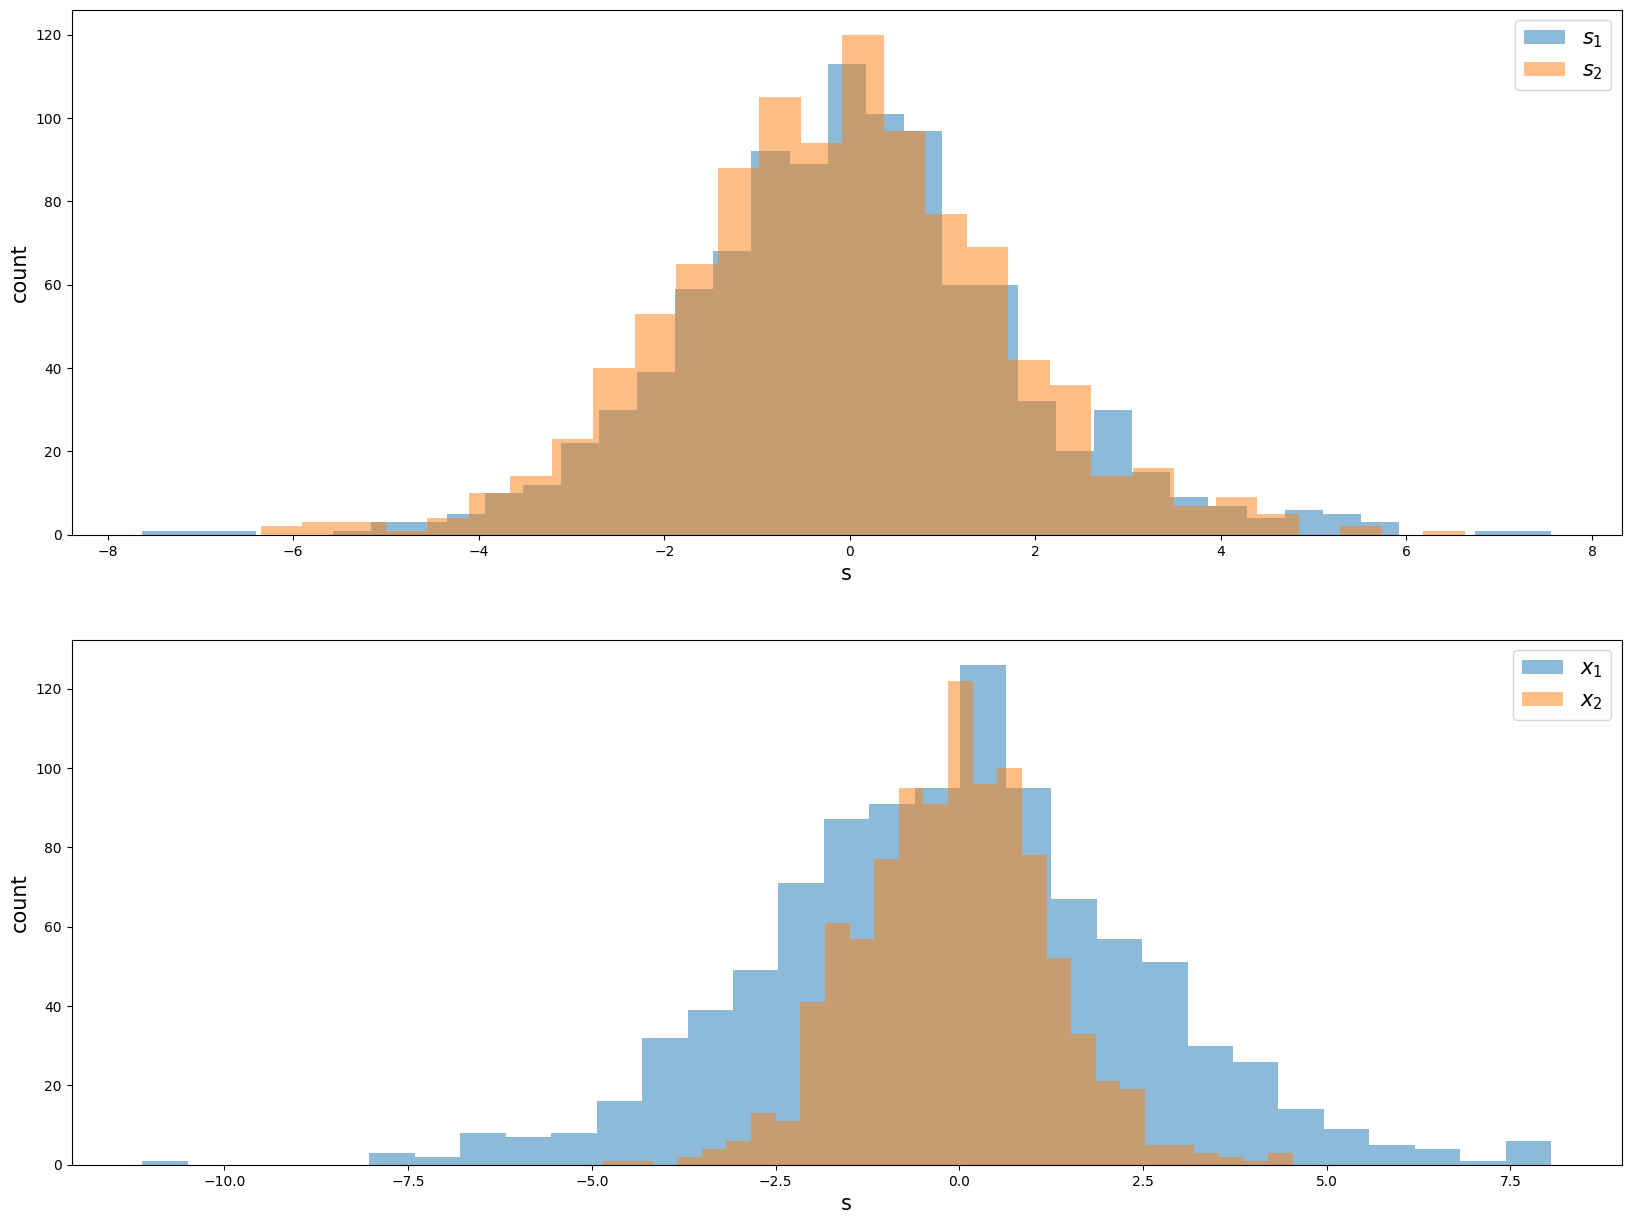

In [4]:
# Number of sources and observations
NSOURCES=2
NOBS=1000

# Mixing matrix configuration
A = np.array([
    [1, 1],
    [-0.5, 0.5]
])

# Ideal separation matrix
B = np.linalg.inv(A)

# Get source realization
s = StandardLogisticSource(
    use_jax=True
).get_realization(
    nsources=NSOURCES,
    nobs=NOBS,
    seed=100
)
# Get mixtures
x = A@s

# Plot
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1, figsize=(20,15)
)

# Ax1
ax1.hist(
    s[0,:],
    bins='fd',
    label='$s_{1}$',
    alpha=0.5
)
ax1.hist(
    s[1,:],
    bins='fd',
    label='$s_{2}$',
    alpha=0.5
)
ax1.legend(fontsize=15)
ax1.set_xlabel(
    's',
    fontsize=15
)
ax1.set_ylabel(
    'count',
    fontsize=15
)

# Ax2
ax2.hist(
    x[0,:],
    bins='fd',
    label='$x_{1}$',
    alpha=0.5
)
ax2.hist(
    x[1,:],
    bins='fd',
    label='$x_{2}$',
    alpha=0.5
)
ax2.legend(fontsize=15)
ax2.set_xlabel(
    's',
    fontsize=15
)
ax2.set_ylabel(
    'count',
    fontsize=15
)


In [5]:

N_SAMPLES=20000
EXPLORATION_VAR = 1E-3
PARALLEL_CHAINS=4
R_HAT_THRESH=1.01
R_HAT_MINIMUM_BURN_IN=5000
R_HAT_EVALUATION_STEP=1000
R_HAT_PERSISTANCE=1
MAX_IT=10000

# Source model pdf
source_pdf = StandardLogisticSource(use_jax=True).get()

# Prior pdf
prior_pdf = ExponentialPrior(
    center=B,
    std=np.inf,
    use_jax=True
).get()

# Initial conditions
initial_condition = jnp.asarray([
    np.add(
        np.random.uniform(
            low=-0.5,
            high=0.5,
            size=B.shape
        ),
        B
    ) for c in range(PARALLEL_CHAINS)
])

mmse = MMSEBarkerMHEstimator(
    n_samples=N_SAMPLES,
    source_pdf_fn=source_pdf,
    prior_pdf_fn=prior_pdf,
    exploration_var=EXPLORATION_VAR,
    parallel_chains=PARALLEL_CHAINS,
    max_it=MAX_IT,
    R_hat_thresh=R_HAT_THRESH,
    R_hat_evaluation_step=R_HAT_EVALUATION_STEP,
    R_hat_persistance=R_HAT_PERSISTANCE,
    R_hat_minimum_burn_in=R_HAT_MINIMUM_BURN_IN,
    auto_adjust_exploration_var=True,
    progress_bar=True
)

samples, diagnostics, logs = mmse.fit(
    x=x,
    initial_condition=initial_condition
)
print('#'*100)
print('B estimado via MMSE:\n{}'.format(mmse.mcmc_results['B_est']))
print('#'*100)

sample: 100%|██████████| 1000/1000 [00:00<00:00, 11920.07it/s, step size 5.27e-01. acc. prob=0.60]

####################################################################################################
B estimado via MMSE:
[[ 0.4841304 -1.024284 ]
 [ 0.5184391  0.9798347]]
####################################################################################################


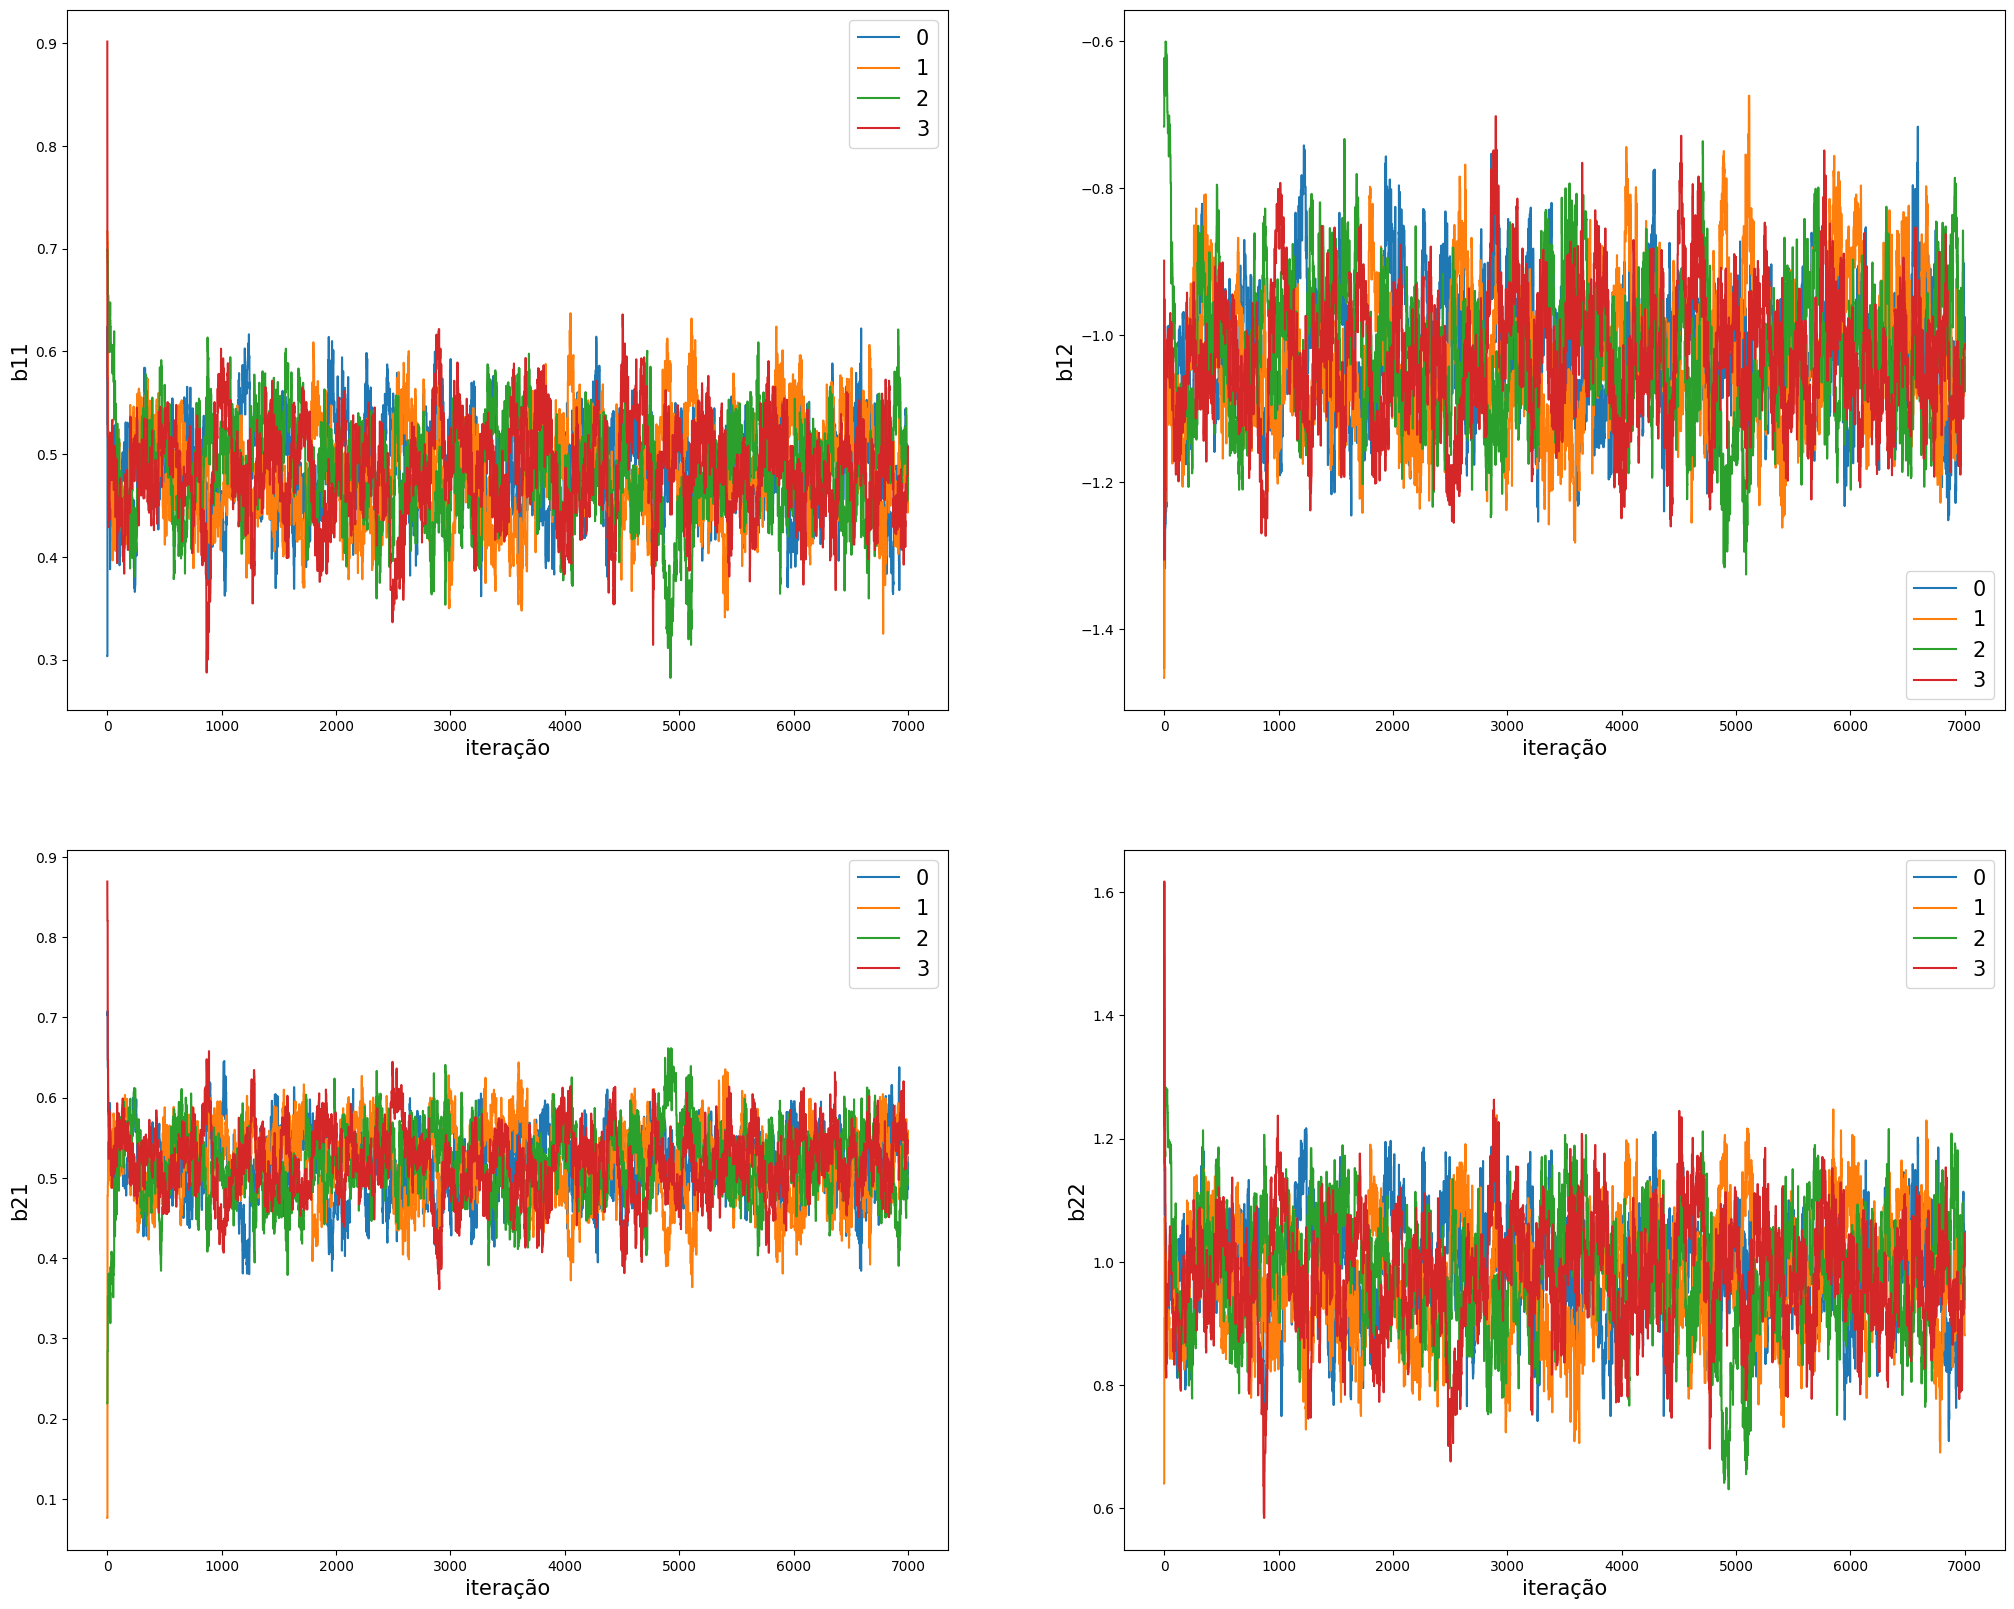

In [6]:
# Plot chain evolutions
fig, axs = plt.subplots(
    nrows=2, ncols=2,
    figsize=(25,20)
)

for i,j in np.ndindex(B.shape):
    for c in range(PARALLEL_CHAINS):
        axs[i,j].plot(
            samples[c][:,i,j],
            label=c
        )
    axs[i,j].legend(
        fontsize=15
    )
    axs[i,j].set_xlabel(
        'iteração',
        fontsize=15
    )
    axs[i,j].set_ylabel(
        'b{}{}'.format(
            i+1,
            j+1
        ),
        fontsize=15
    )

<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_53319/2285946103.py:44: SyntaxWarning: invalid escape sequence '\h'
  '$\hat{R}$',


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,6000,1.004190,207.265059,1.003776,201.478645,1.003442,208.807055,1.004754,201.367457
1,7000,1.004487,206.651117,1.003247,199.193382,1.003994,206.748750,1.003369,208.697136


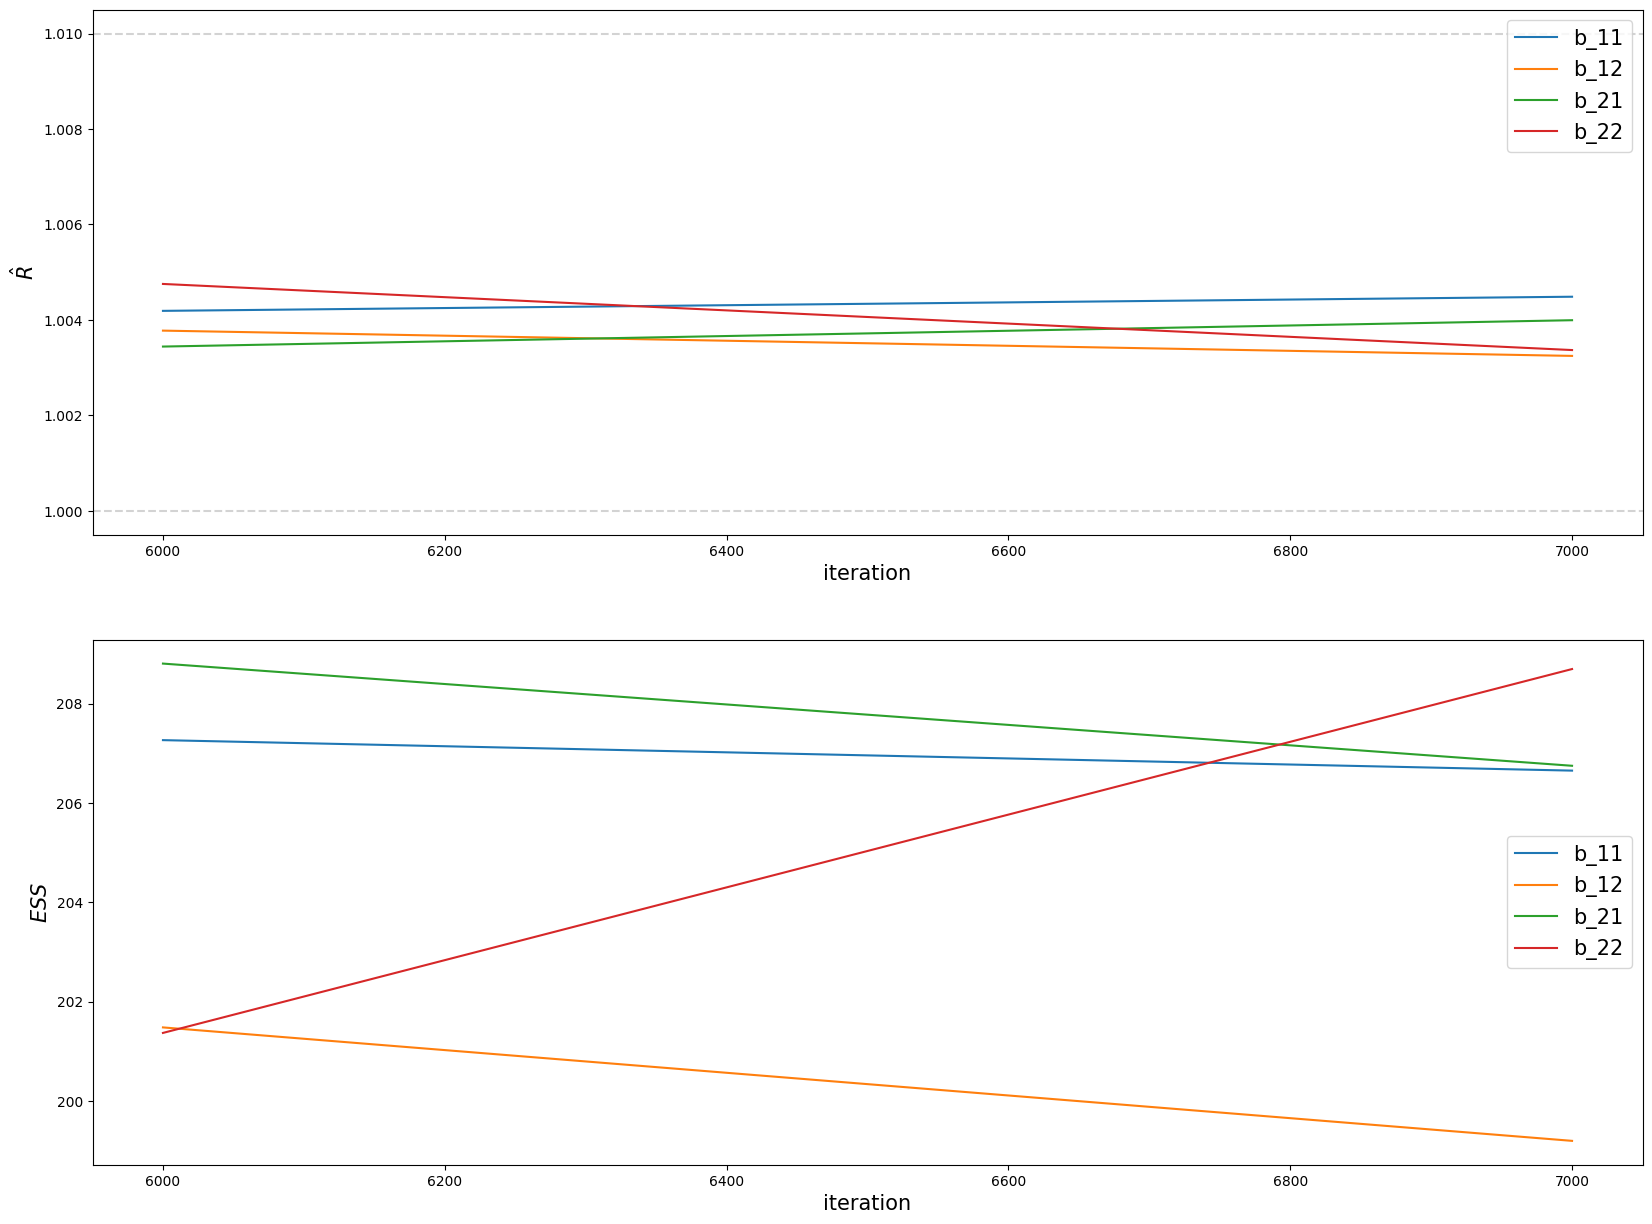

In [7]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(20,15)
)

# Get R-hat columns
R_hat_cols = [c for c in diagnostics.columns if 'r_hat' in c]

# Get ESS columns
ESS_cols = [c for c in diagnostics.columns if 'ess' in c]

for c in R_hat_cols:
    ax1.plot(
        diagnostics.iteration,
        diagnostics[c],
        label=c[-4:]
    )

for c in ESS_cols:
    ax2.plot(
        diagnostics.iteration,
        diagnostics[c],
        label=c[-4:]
    )

ax1.axhline(
    1,
    c='lightgray',
    linestyle='--'
)

ax1.axhline(
    R_HAT_THRESH,
    c='lightgray',
    linestyle='--'
)

ax1.set_xlabel(
    'iteration',
    fontsize=15
)

ax1.set_ylabel(
    '$\hat{R}$',
    fontsize=15
)

l1=ax1.legend(
    fontsize=15
)

ax2.set_xlabel(
    'iteration',
    fontsize=15
)

ax2.set_ylabel(
    '$ESS$',
    fontsize=15
)

l2=ax2.legend(
    fontsize=15
)

diagnostics

100%|██████████| 558/558 [00:00<00:00, 5490.66it/s]


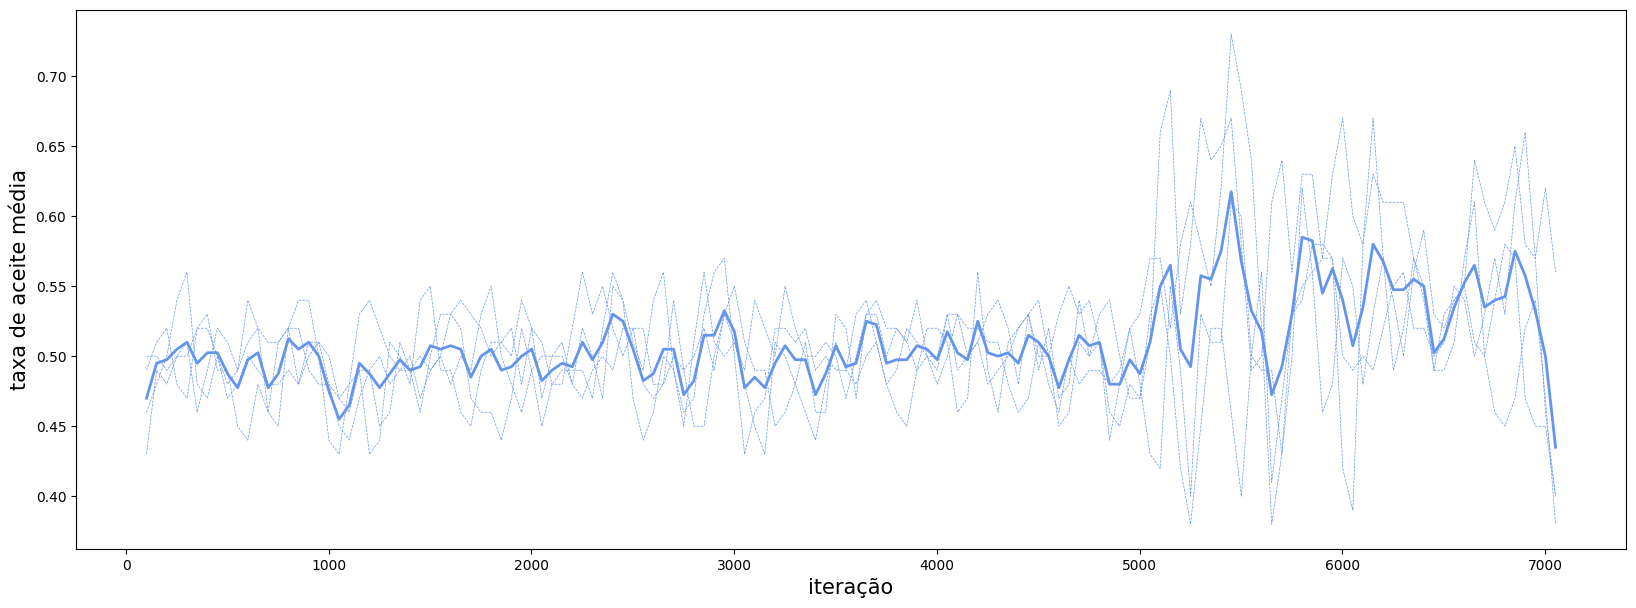

In [8]:
WDW_SIZE=100
STEP_SIZE=50
avg_acceptances = {c: [] for c in logs.chain.unique()}
evaluated_its=range(WDW_SIZE+1, logs.shape[0]+1, STEP_SIZE)
for c, group in logs.groupby(
        by=['chain']
    ):
    c=c[0]
    for i in tqdm(evaluated_its):
        mean_accept = group[
            (group.inside_iteration<i)&
            (group.inside_iteration>=i-WDW_SIZE)
        ].save_new_sample.astype(float).mean()
        avg_acceptances[c].append(mean_accept)

overall_acceptance = np.array([
    logs[
        (logs.inside_iteration<i)&
        (logs.inside_iteration>=i-WDW_SIZE)
    ].save_new_sample.astype(float).mean() for i in evaluated_its
])

fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(20,7)
)

ax.set_xlabel(
    'iteração',
    fontsize=15
)
ax.set_ylabel(
    'taxa de aceite média',
    fontsize=15
)

for c, alphas in avg_acceptances.items():
    ax.plot(
        evaluated_its,
        avg_acceptances[c],
        linestyle = '--',
        linewidth=.5,
        color='cornflowerblue',
        label=c
    )

ax.plot(
    evaluated_its,
    overall_acceptance,
    linewidth=2,
    color='cornflowerblue'
)



# 3. Executar Amostragem de Importância

In [9]:
def visualize_weights(
    results_is,
    samples,
    true_B,
    param_name,
    alpha=0.5,
    n_curves=None
):
    
    

    # Get distances from samples to true B's
    dist_true_B = np.array([
        np.linalg.norm(
            np.subtract(true_B, B_k)
        ) for B_k in samples
    ])
    for analysis_type, analysis_results in results_is.items():
        # Get indexes of plotted curves
        if n_curves is not None:
            plotted_idxs = [
               int(idx) for idx in np.linspace(0, len(analysis_results['params'])-1, n_curves)
            ]
        fig, (ax1, ax2) = plt.subplots(
            nrows=2, ncols=1,
            figsize=(20,15)
        )
        fig.suptitle(
            analysis_type,
            fontsize=15
        )
        for i, w, param in zip(
            range(len(analysis_results['params'])),
            analysis_results['weights'],
            analysis_results['params']
        ):
            if i in plotted_idxs:
                ax1.hist(
                    w,
                    bins='auto',
                    label='{}={}'.format(param_name, f"{param:.3e}"),
                    alpha=alpha,
                    log=True
                )

                ax2.scatter(
                    dist_true_B,
                    w,
                    label='{}={}'.format(param_name, f"{param:.3e}"),
                )
        ax1.set_xlabel(
            'weight',
            fontsize=15
        )
        ax1.set_ylabel(
            'count',
            fontsize=15
        )
        ax1.legend()

        ax2.set_xlabel(
            '||B-B_k||_F',
            fontsize=15
        )
        ax2.set_ylabel(
            'weight',
            fontsize=15
        )
        ax2.legend()




In [10]:
def visualize_estimates(
    results_is,
    true_B,
    param_name
):
    def __estimate_plot(
        results,
        var_type,
        true_B,
        param_name
    ):
        fig, axs = plt.subplots(
            nrows=2, ncols=2,
            figsize=(25,15)
        )

        for i, j in np.ndindex(true_B.shape):
            axs[i,j].set_xscale('log')
            axs[i,j].plot(
                results['params'],
                np.array(results[var_type+'s'])[:,i,j],
                color='cornflowerblue'
            )
            if var_type=='mean':
                axs[i,j].axhline(
                    true_B[i,j],
                    color='gray',
                    linestyle='--'
                )
            axs[i,j].set_xlabel(
                param_name,
                fontsize=15
            )
            axs[i,j].set_ylabel(
                '{}(b_{}{})'.format(
                    var_type,
                    i+1,
                    j+1
                ),
                fontsize=15
            )


    for analysis_type, analysis_results in results_is.items():
        _ = [
            __estimate_plot(
                results=analysis_results,
                var_type=v,
                true_B=true_B,
                param_name=param_name
            ) for v in [
                'mean',
                'var',
                'skew',
                'kurt'
            ]
        ]

## Variação da escala da prior

In [11]:
# Run priors with different variances
target_scales = jnp.logspace(
    start=-2,
    stop=1,
    num=100,
    base=10
)
target_priors = [
    ExponentialPrior(
        center=B,
        std=sigma_B,
        use_jax=True
    ) for sigma_B in target_scales
]

results = ImportanceSamplingEstimator.run(
    samples=mmse.mcmc_results['samples'],
    baseline_prior=ExponentialPrior(
        center=B,
        std=np.inf,
    ),
    x=x,
    target_priors=target_priors,
    prior_control_params=target_scales,
    baseline_source_model=StandardLogisticSource(),
    target_source_models=None,
    source_model_control_params=None
)

100%|██████████| 100/100 [09:48<00:00,  5.88s/it]  


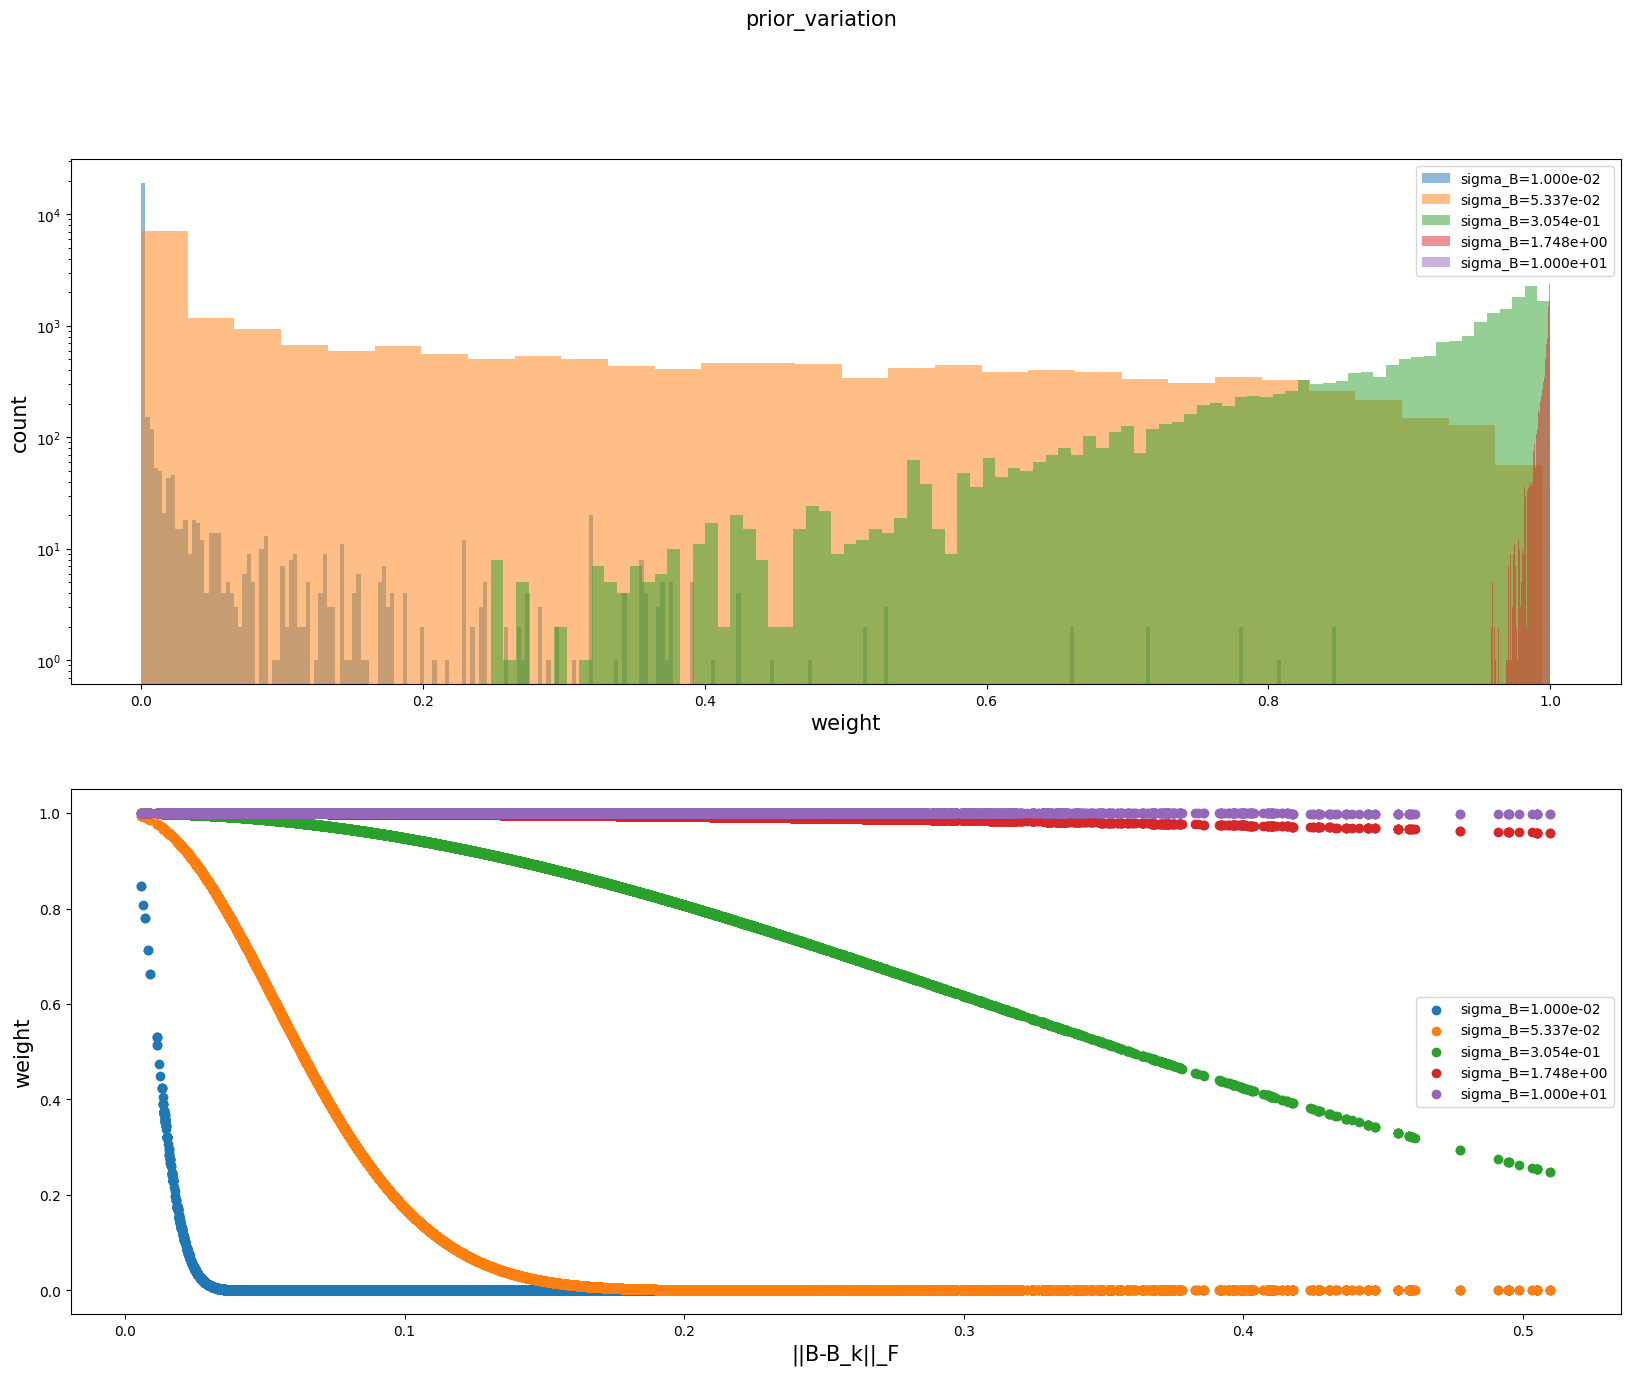

In [12]:
visualize_weights(
    results_is=results,
    samples=mmse.mcmc_results['samples'],
    true_B=B,
    param_name='sigma_B',
    alpha=0.5,
    n_curves=5
)

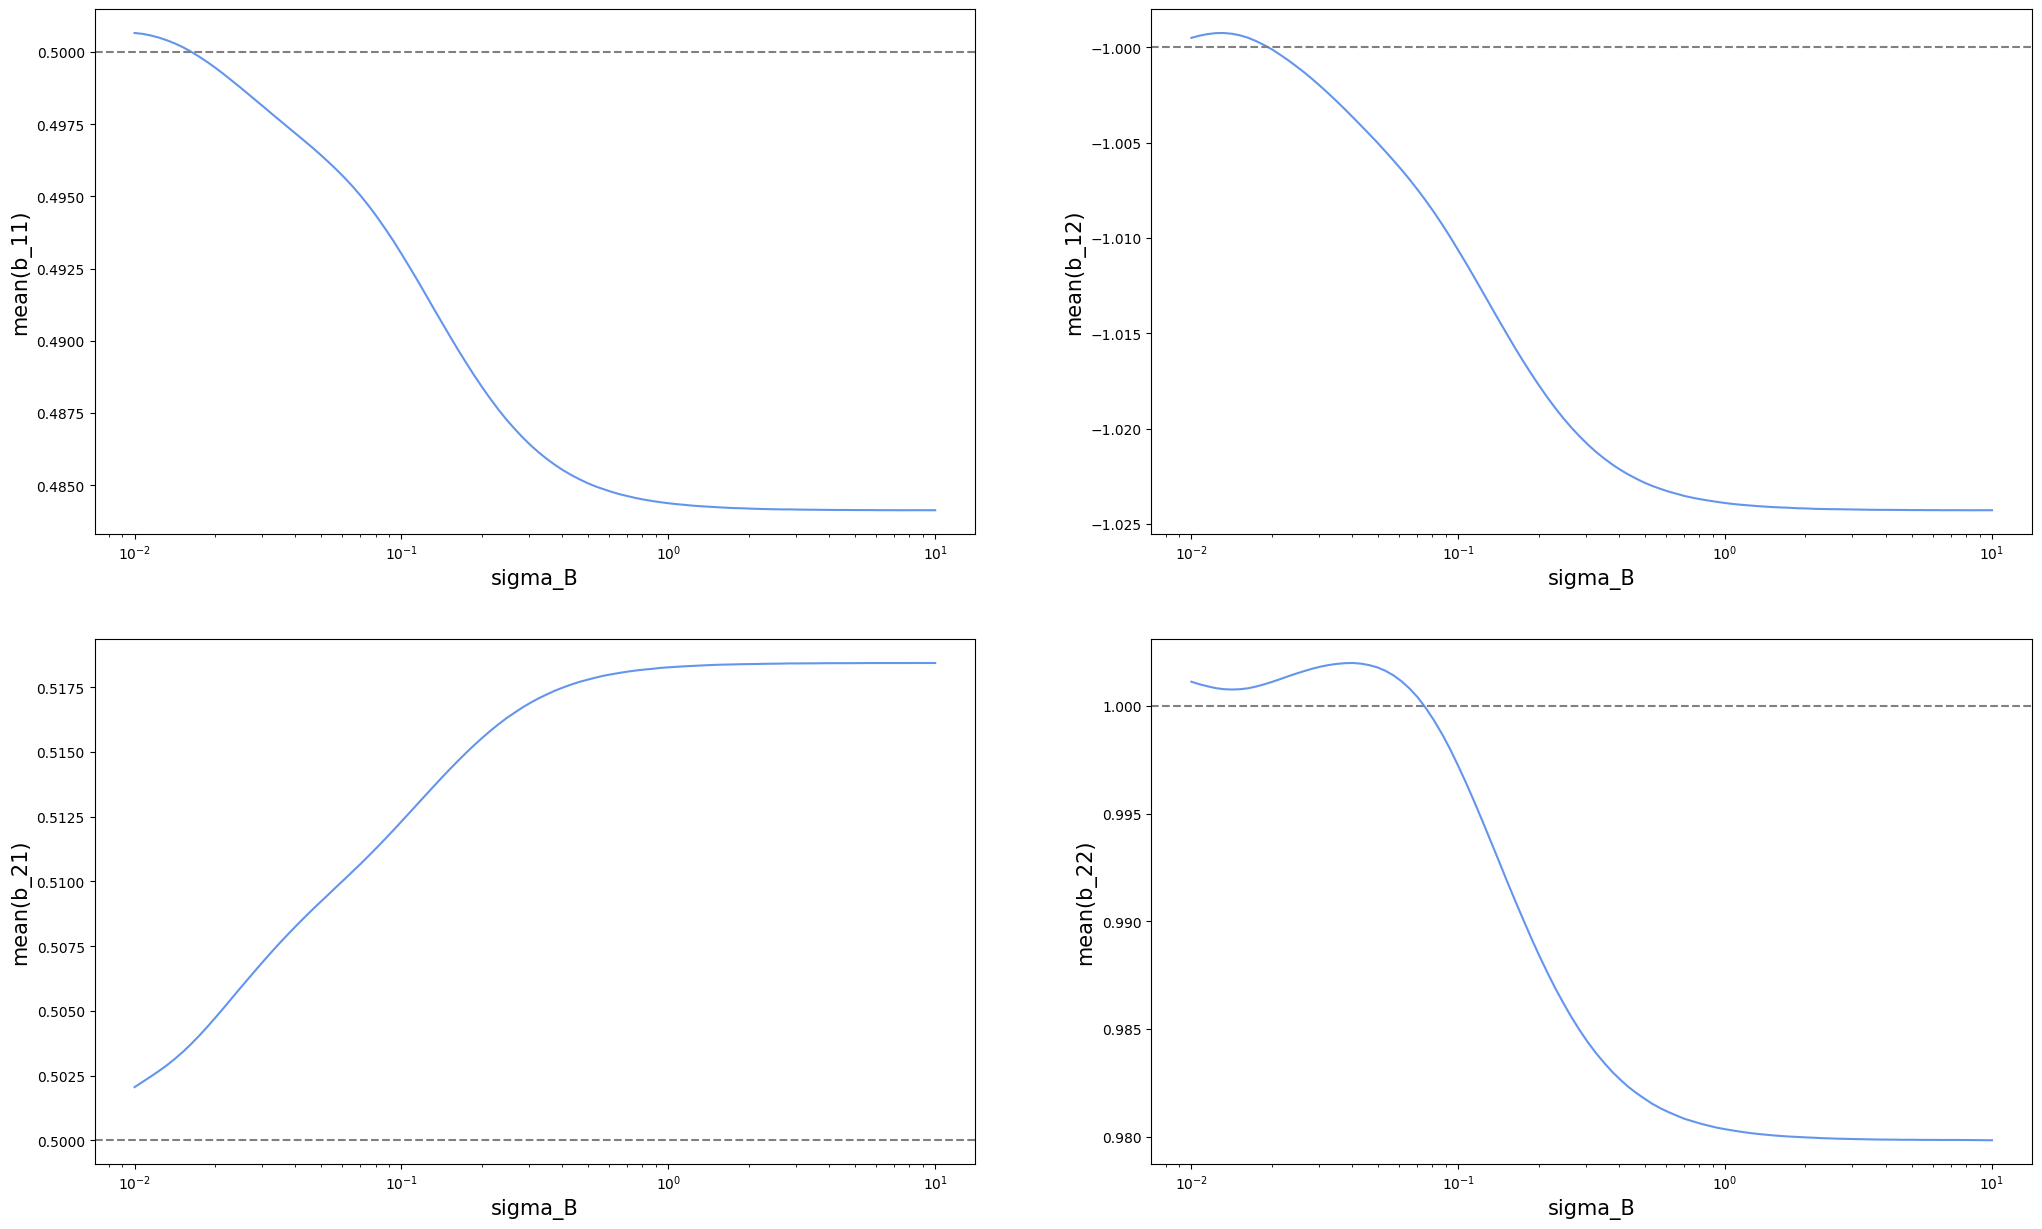

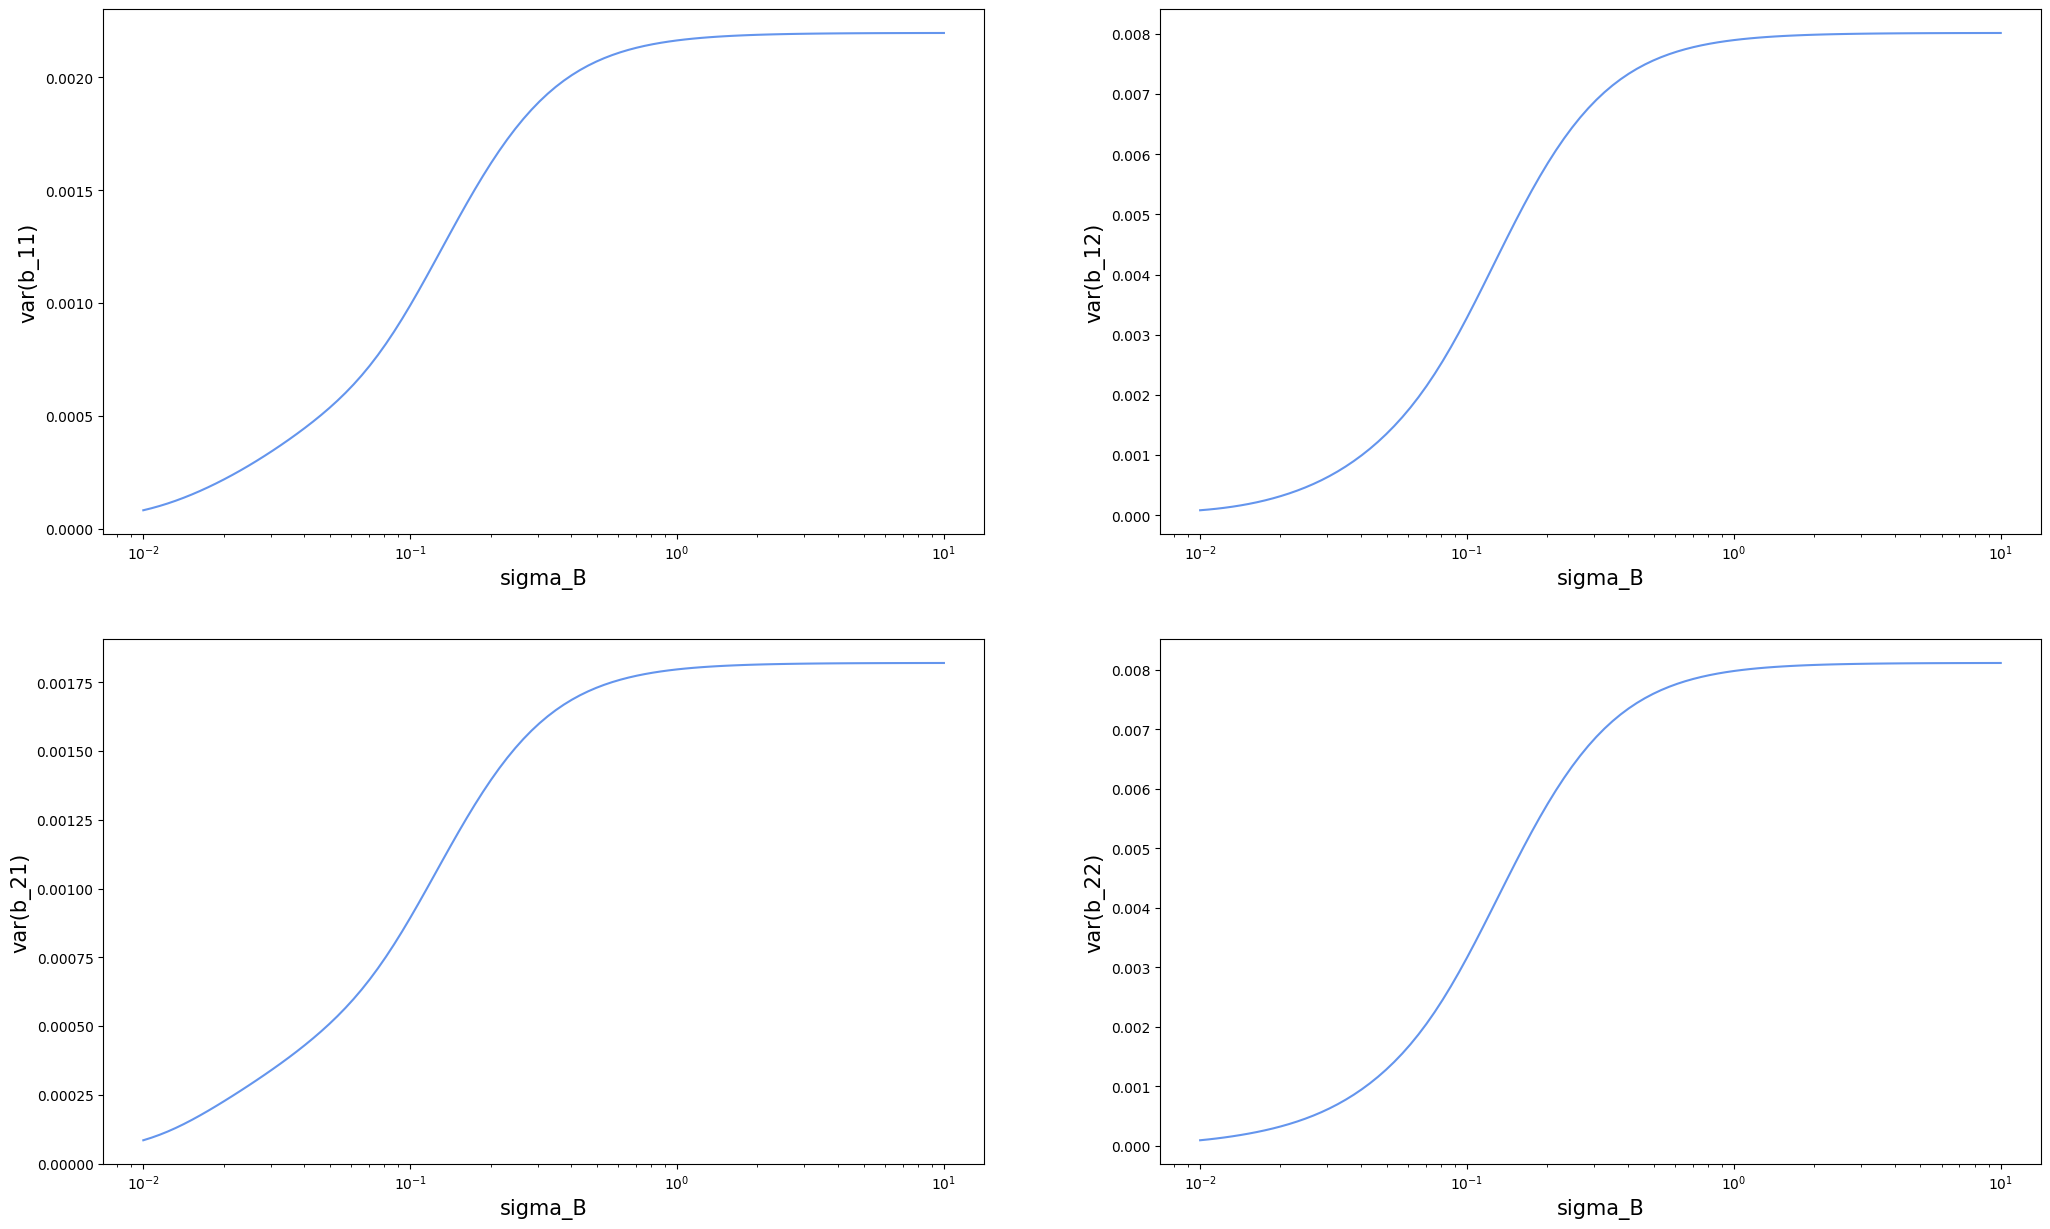

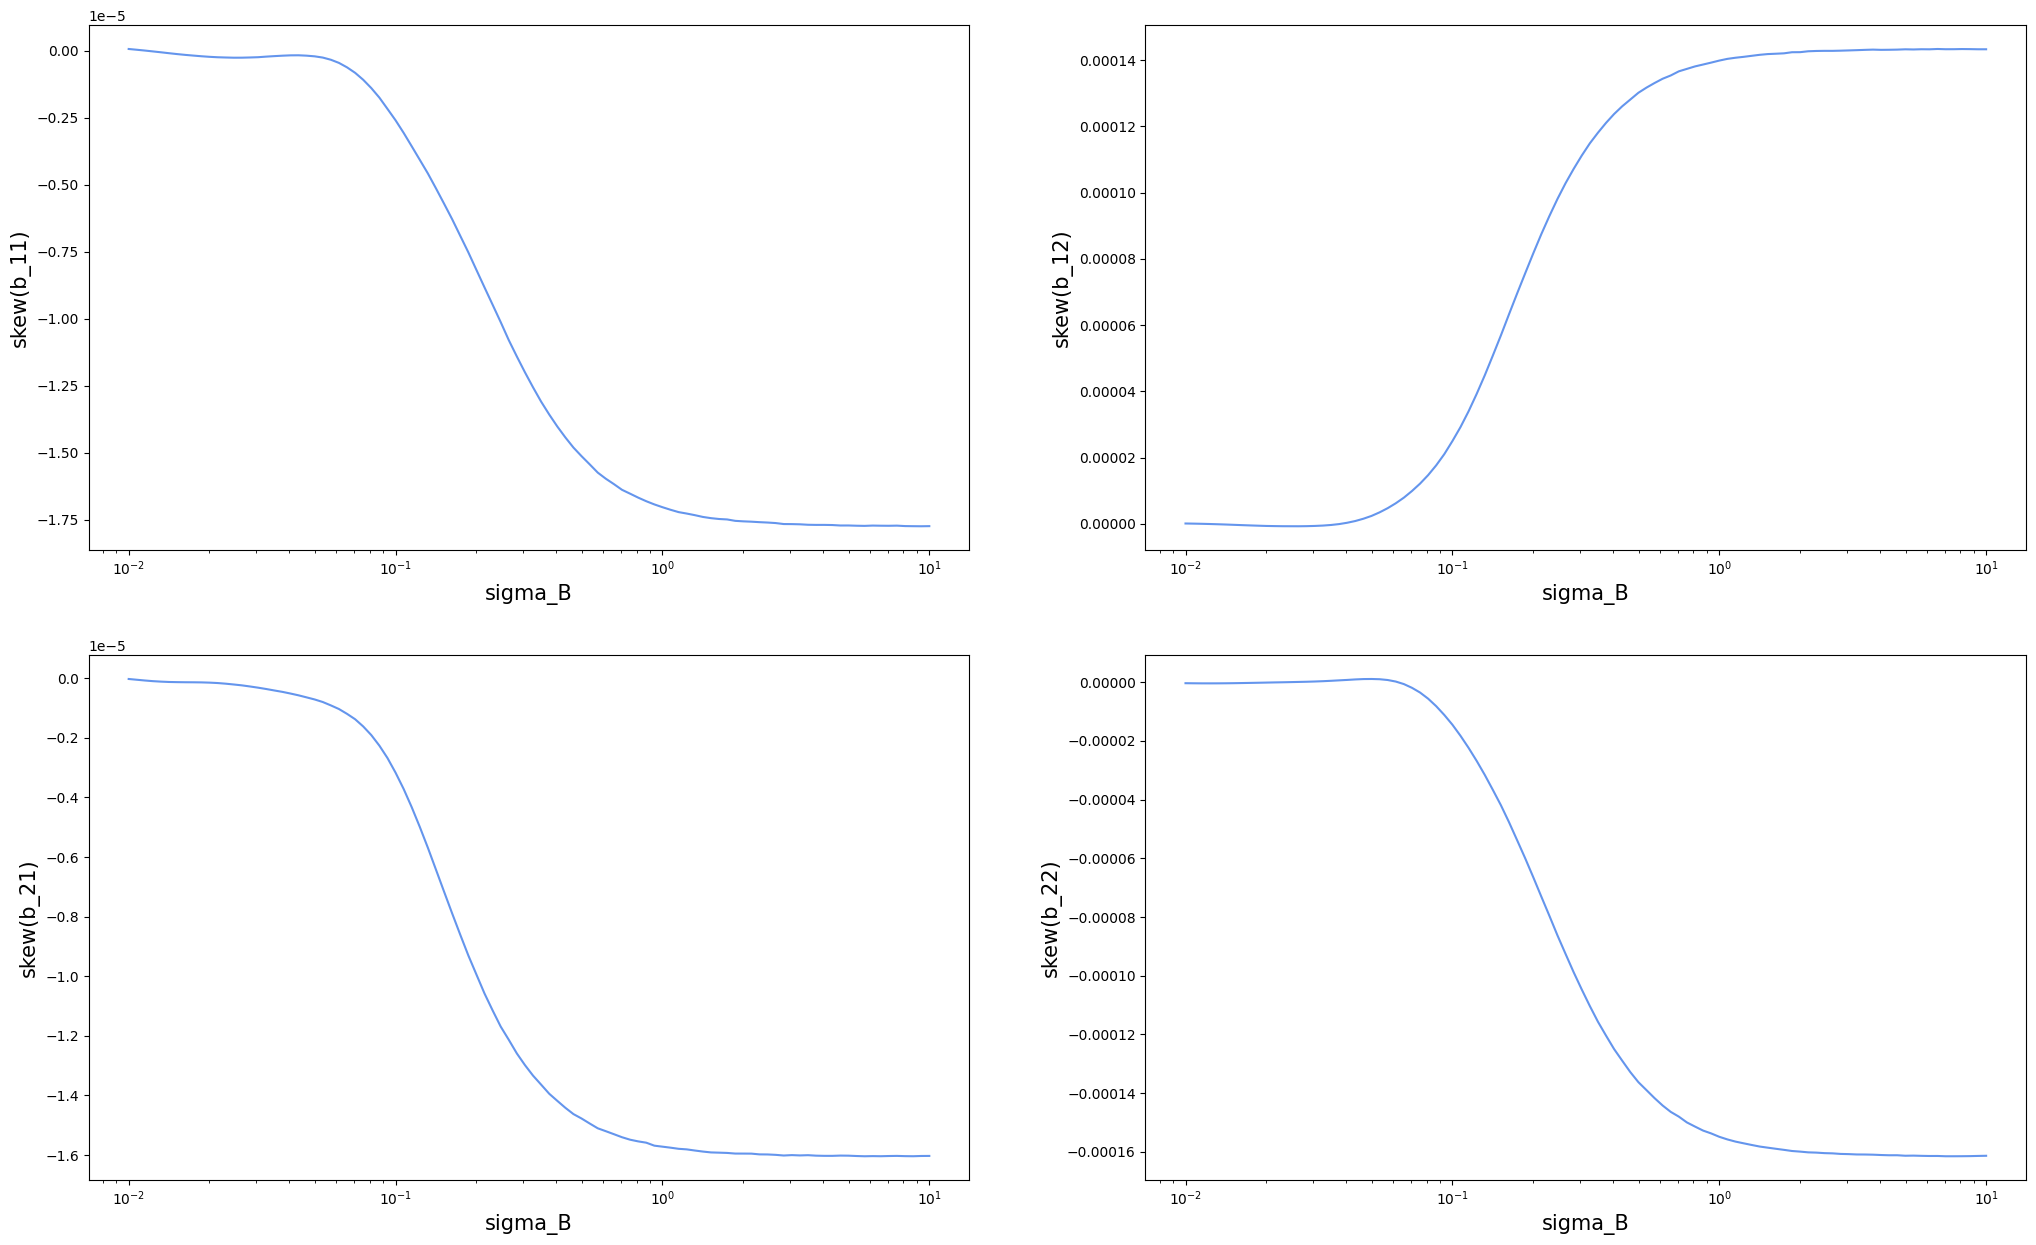

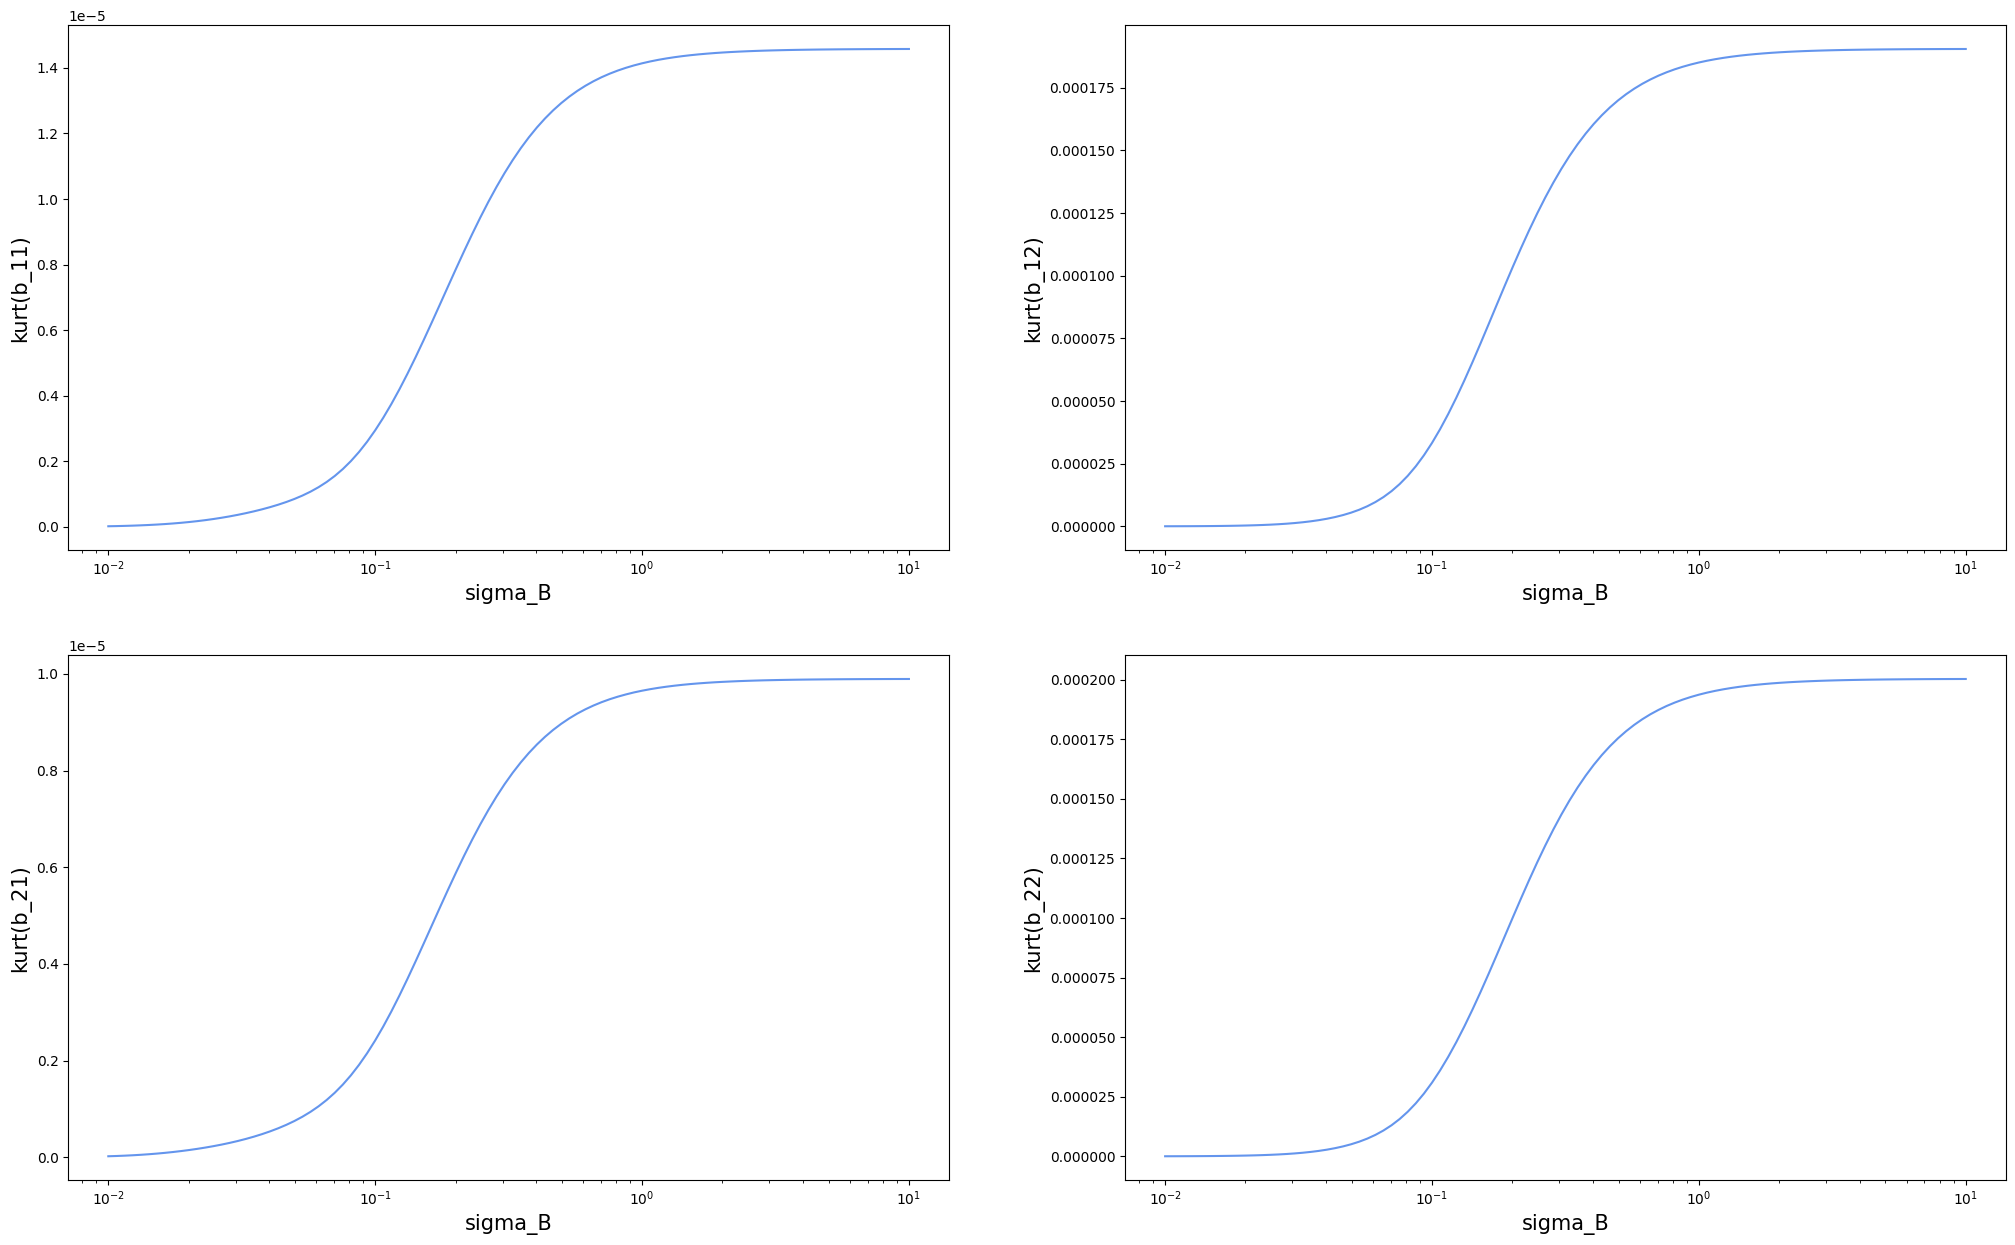

In [13]:
visualize_estimates(
    results_is=results,
    true_B=B,
    param_name='sigma_B'
)

## Variação da moda da prior

In [14]:
def visualize_estimate_intervals(
    results_is,
    true_B,
    param_name,
    param_threshs,
):
    # def __get_
    def __estimate_plot(
        results,
        vars_threshed,
        threshs,
        var_type,
        true_B,
        param_name
    ):

        fig, axs = plt.subplots(
            nrows=2, ncols=2,
            figsize=(25,15)
        )

        for i, j in np.ndindex(true_B.shape):
            # Get value of variable for index
            vars_threshed_values = np.array(
                [
                    np.array(arr)[:,i,j] if len(arr)>0 else np.array([]) for arr in vars_threshed[var_type+'s']
                ],
                dtype='object'
            )

            # Get statistics for each thresh value
            stats_threshed_values={}
            stats_threshed_values['max'] = [
                np.max(arr) if len(arr)>0 else np.nan for arr in vars_threshed_values
            ]
            stats_threshed_values['median'] = [
                np.median(arr) if len(arr)>0 else np.nan for arr in vars_threshed_values
            ]
            stats_threshed_values['min'] = [
                np.min(arr) if len(arr)>0 else np.nan for arr in vars_threshed_values
            ]

            # axs[i,j].set_xscale('log')
            axs[i,j].plot(
                threshs,
                stats_threshed_values['max'],
                color='cornflowerblue',
                linestyle='--',
                linewidth=.5
            )
            axs[i,j].plot(
                threshs,
                stats_threshed_values['min'],
                color='cornflowerblue',
                linestyle='--',
                linewidth=.5
            )
            axs[i,j].plot(
                threshs,
                stats_threshed_values['median'],
                color='cornflowerblue',
                linewidth=2
            )
            if var_type=='mean':
                axs[i,j].axhline(
                    true_B[i,j],
                    color='gray',
                    linestyle='--'
                )
            axs[i,j].set_xlabel(
                param_name,
                fontsize=15
            )
            axs[i,j].set_ylabel(
                '{}(b_{}{})'.format(
                    var_type,
                    i+1,
                    j+1
                ),
                fontsize=15
            )


    for analysis_type, analysis_results in results_is.items():
        # import pdb; pdb.set_trace()
        # Get samples within thresh, for each thresh
        vars_threshed = {
            v+'s': np.array(
                [
                    np.array(analysis_results[v+'s'])[
                            np.where(
                            analysis_results['params']<t
                        )[0]
                    ] for t in param_threshs
                ],
                dtype=object
            ) for v in [
                'mean',
                'var',
                'skew',
                'kurt'
            ]
        }
        # import pdb; pdb.set_trace()
        _ = [
            __estimate_plot(
                results=analysis_results,
                vars_threshed=vars_threshed,
                threshs=param_threshs,
                var_type=v,
                true_B=true_B,
                param_name=param_name
            ) for v in [
                'mean',
                'var',
                'skew',
                'kurt'
            ]
        ]

In [15]:
# Run priors with different variances
MAX_RADIUS=1
N_PRIORS=500
modes = np.array([
    np.add(
        B,
        U
    ) for U in np.random.uniform(
        low=-MAX_RADIUS,
        high=MAX_RADIUS,
        size=(
            N_PRIORS,
            B.shape[0],
            B.shape[-1]
        )
    )
])
mode_distances = np.array([
    np.linalg.norm(
        np.subtract(B, B_k)
    ) for B_k in modes
])

target_priors = [
    ExponentialPrior(
        center=B_k,
        std=1,
        use_jax=True
    ) for B_k in modes
]

results = ImportanceSamplingEstimator.run(
    samples=mmse.mcmc_results['samples'],
    baseline_prior=ExponentialPrior(
        center=B,
        std=np.inf,
    ),
    x=x,
    target_priors=target_priors,
    prior_control_params=mode_distances,
    baseline_source_model=StandardLogisticSource(),
    target_source_models=None,
    source_model_control_params=None
)

100%|██████████| 500/500 [23:26<00:00,  2.81s/it]  


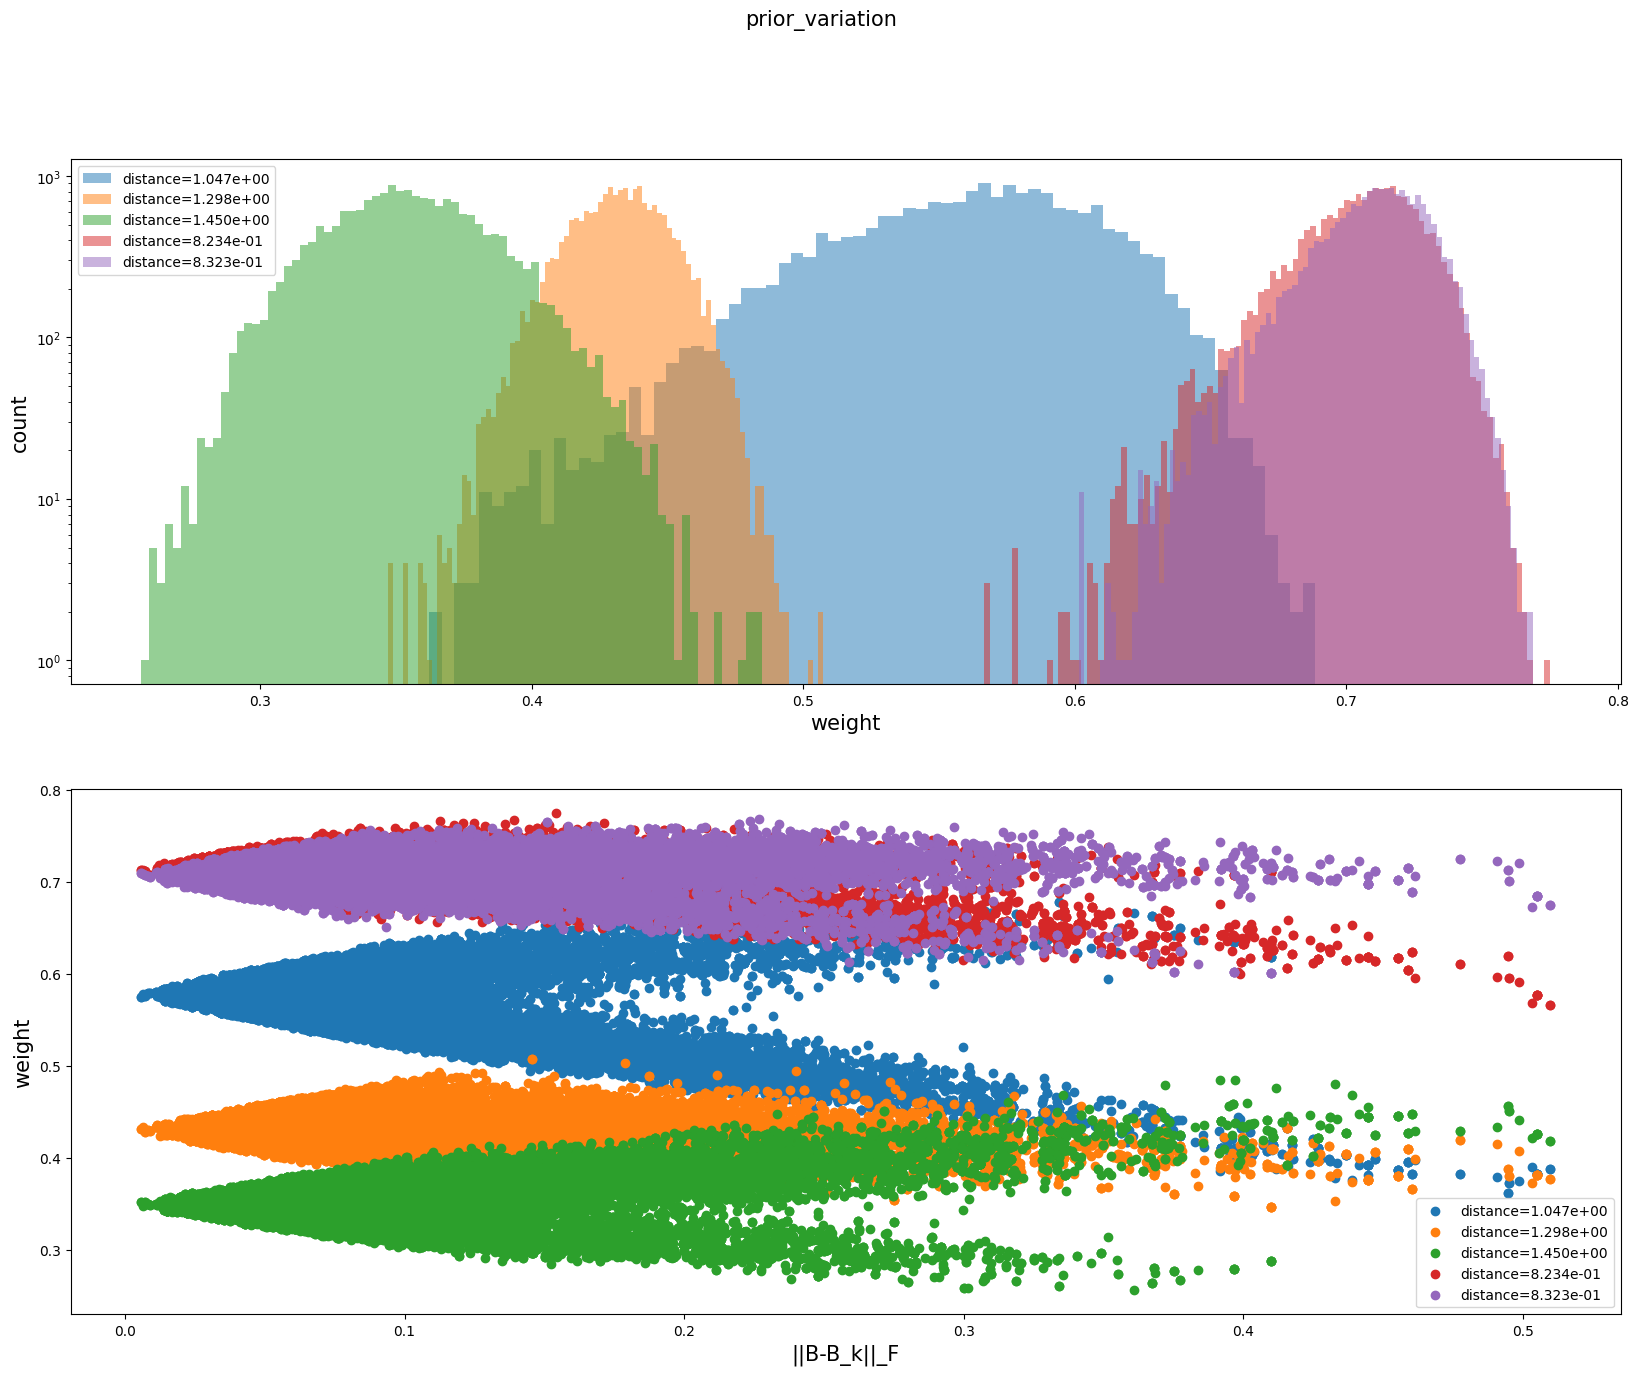

In [16]:
visualize_weights(
    results_is=results,
    samples=mmse.mcmc_results['samples'],
    true_B=B,
    param_name='distance',
    alpha=0.5,
    n_curves=5
)

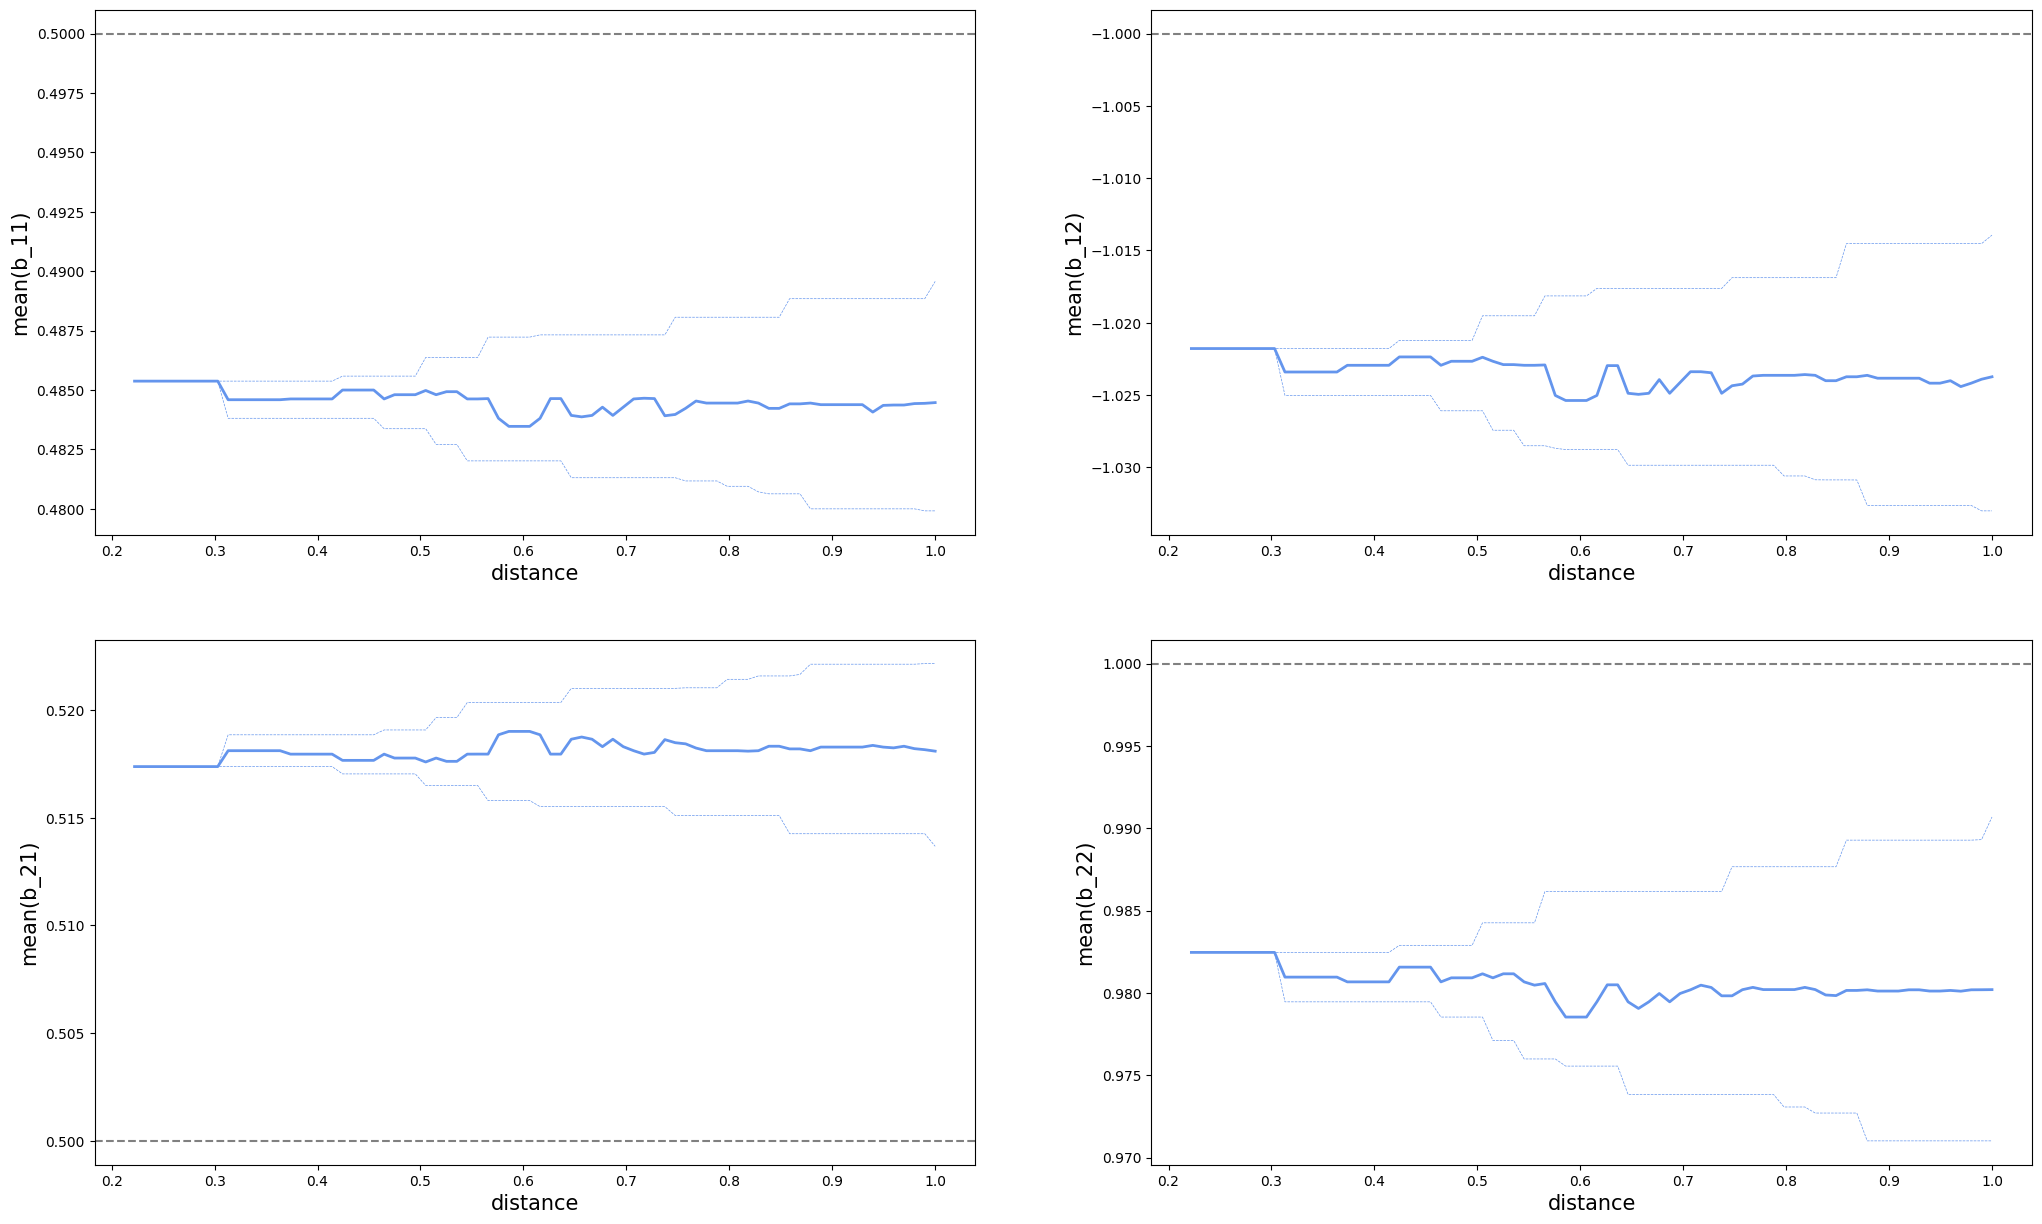

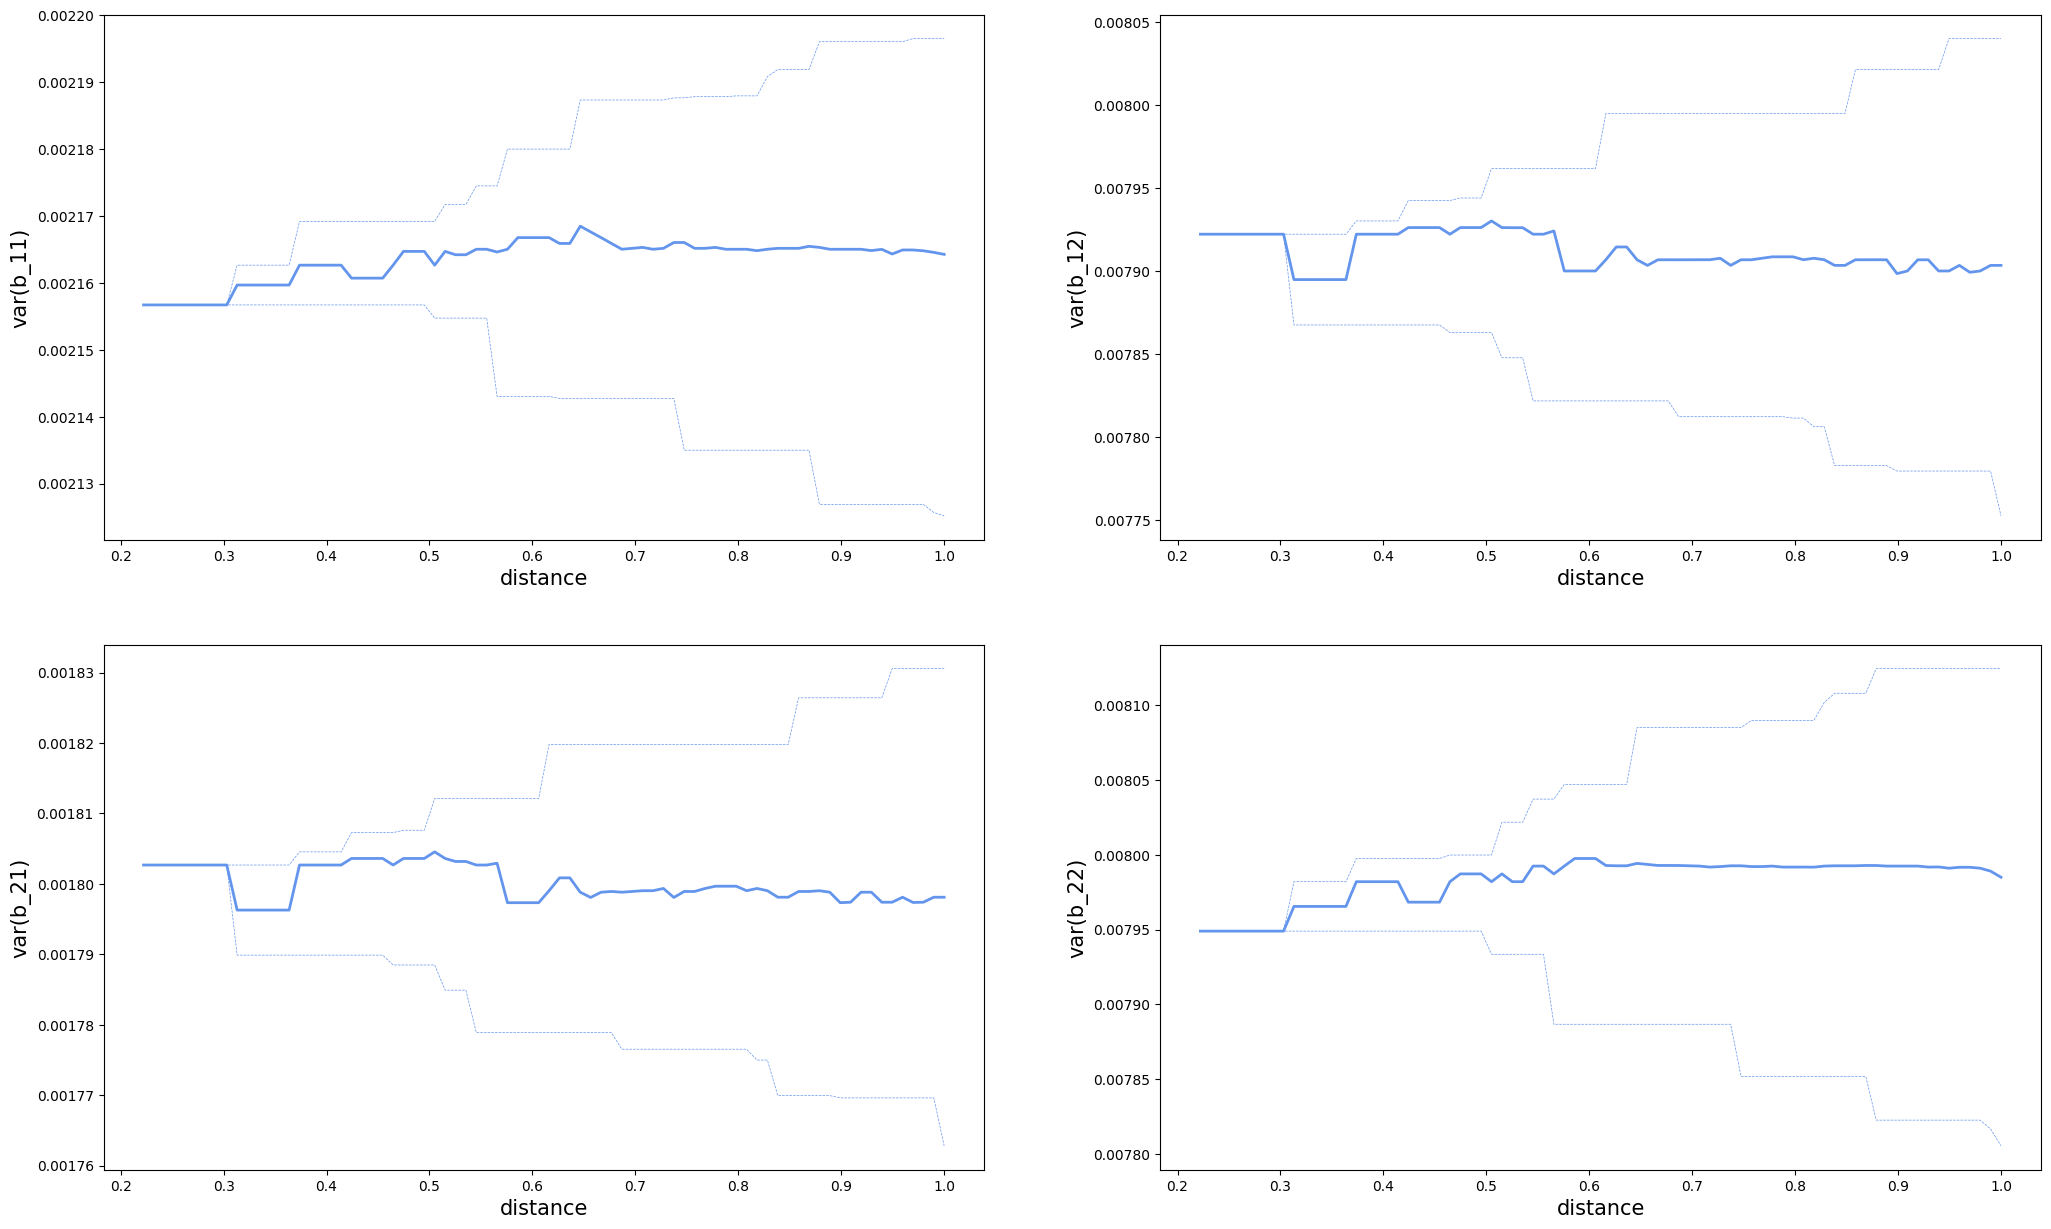

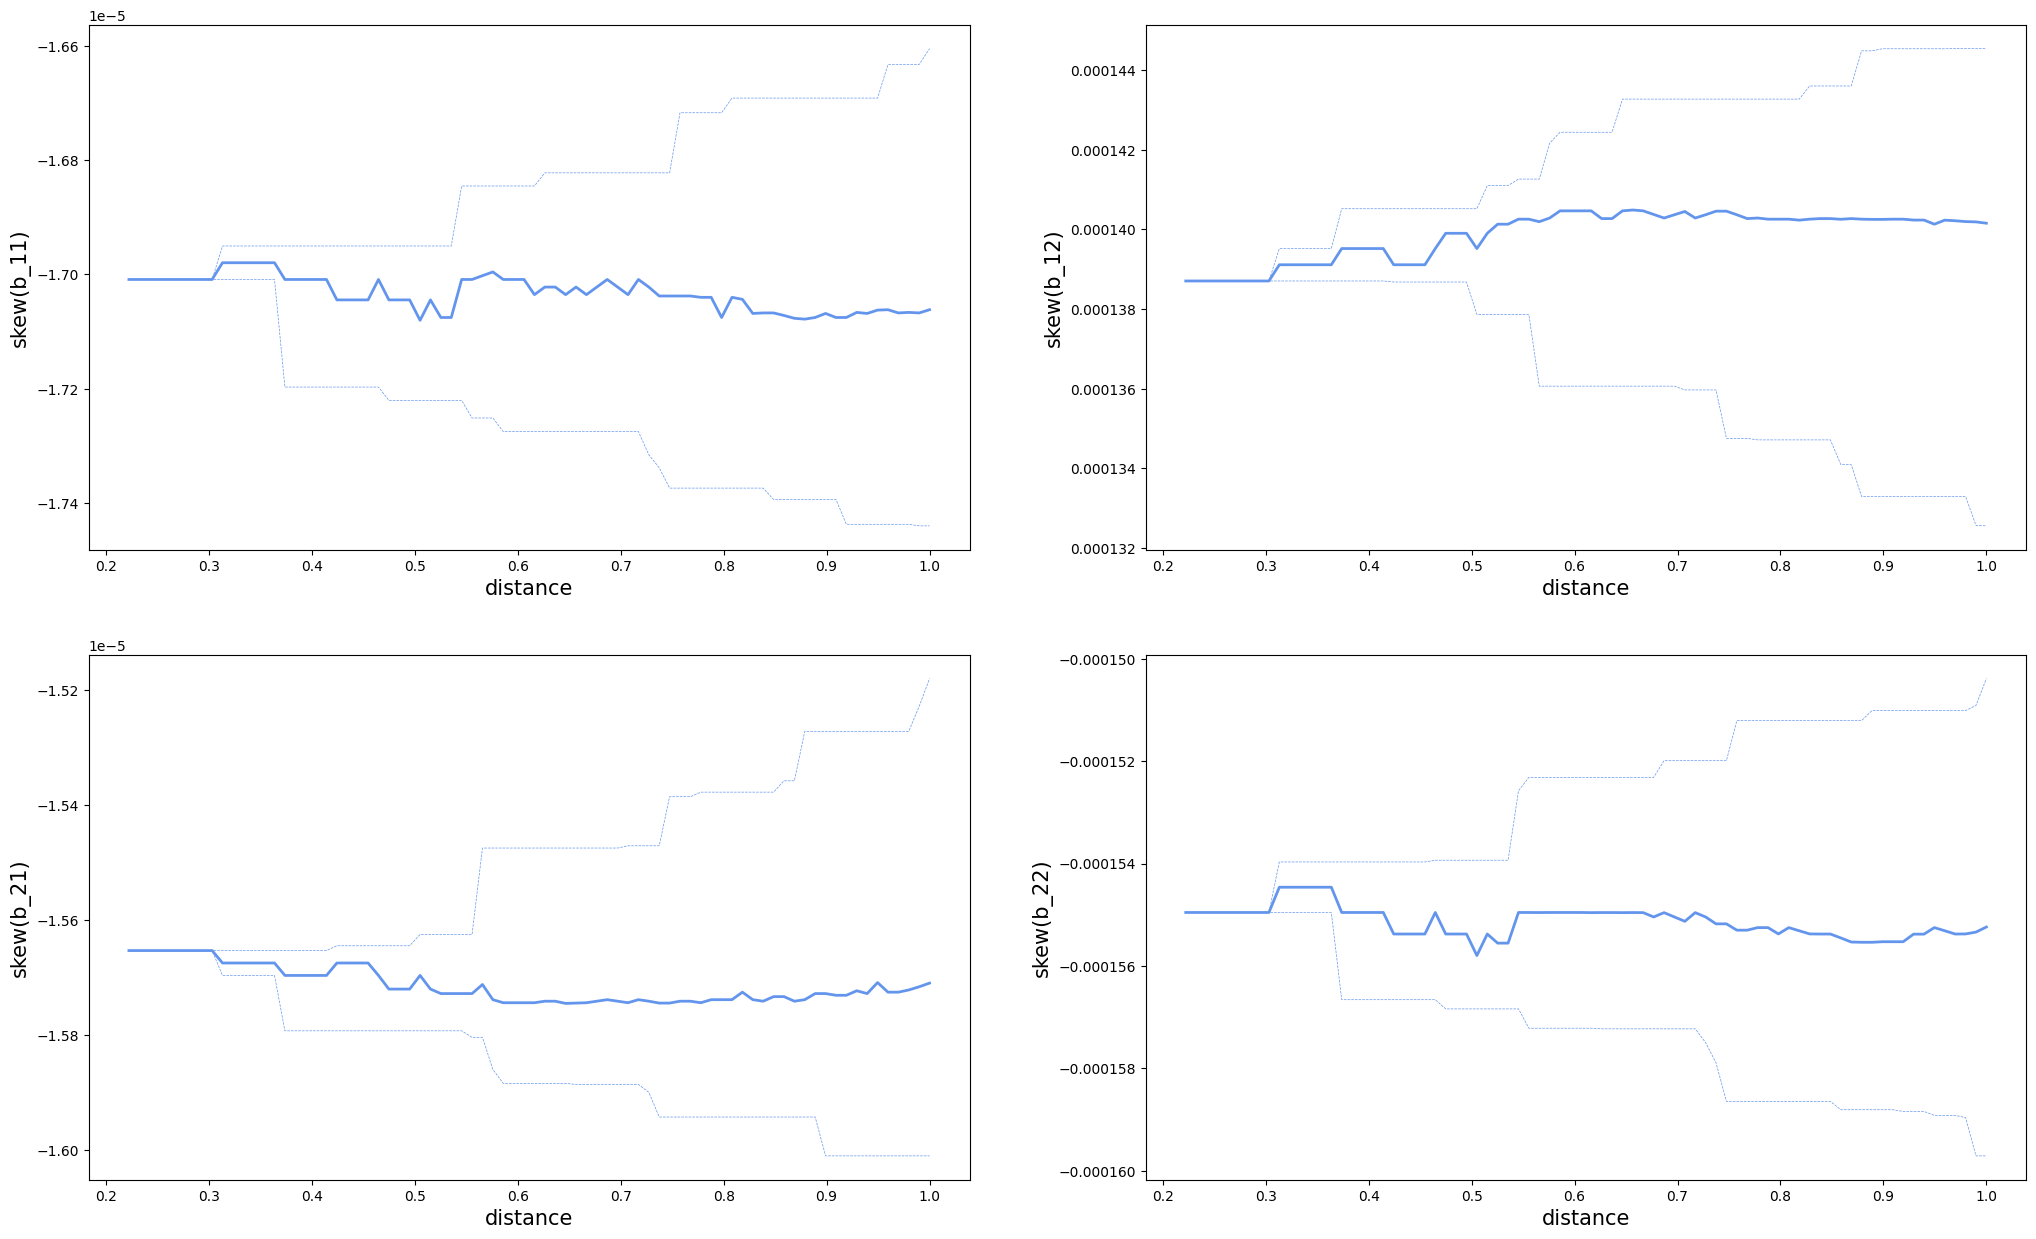

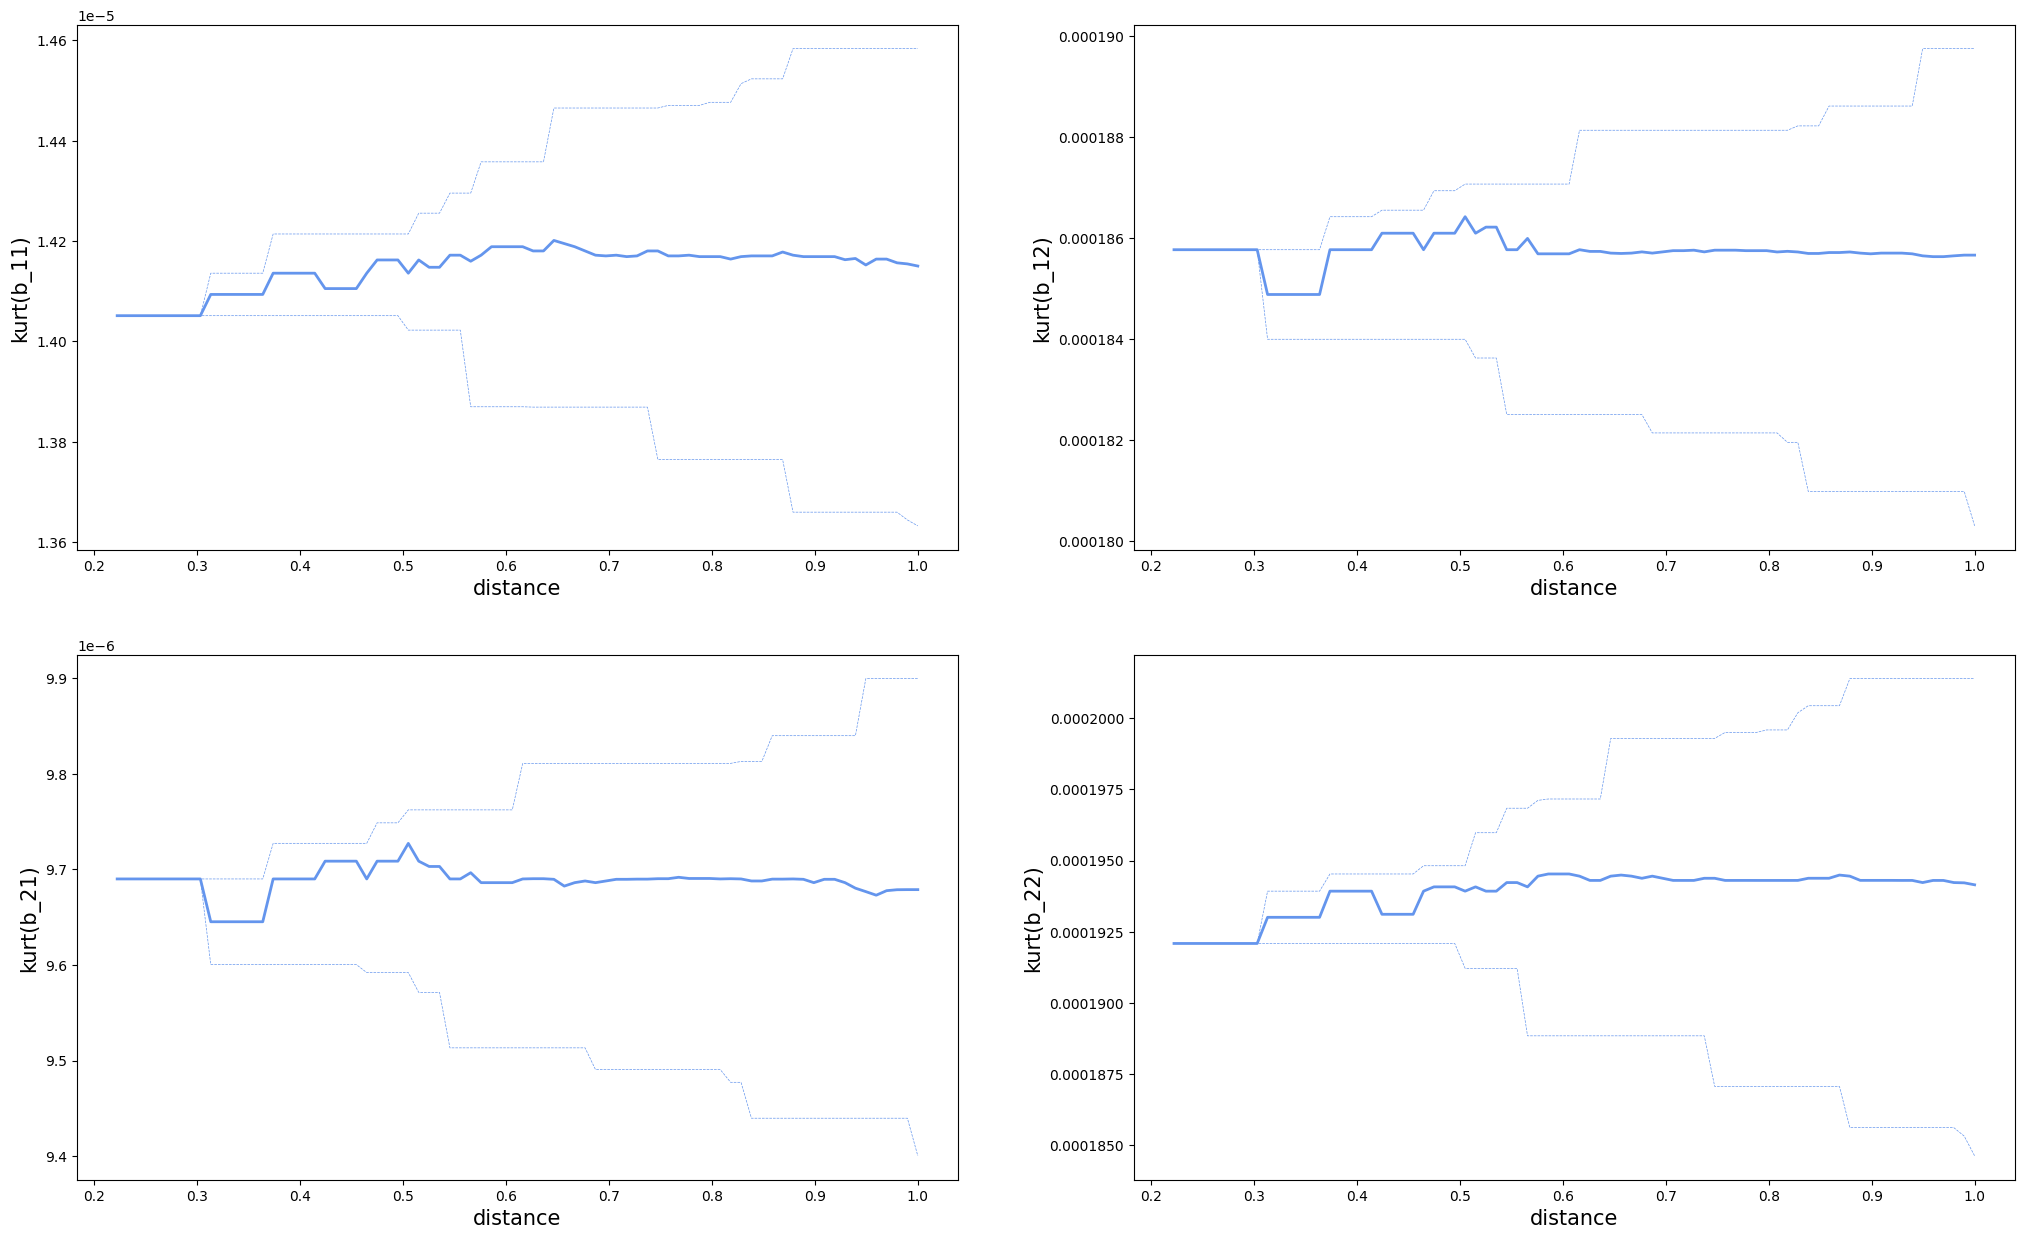

In [17]:
dist_threshs = np.linspace(
    0,
    MAX_RADIUS,
    100
)

visualize_estimate_intervals(
    results_is=results,
    true_B=B,
    param_name='distance',
    param_threshs=dist_threshs
)